In [26]:
# =============================================================================
# Hepatitis C Dataset — Initial Exploration (Google Colab)
# Source: https://www.kaggle.com/datasets/fedesoriano/hepatitis-c-dataset
# Loaded via KaggleHub. The dataset is inspected only — nothing is modified.
# =============================================================================

# Install KaggleHub (safe to re-run; quiet in Colab)
!pip install -q kagglehub

import os
import glob
import kagglehub
import pandas as pd

# Show all columns / avoid truncation when printing
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# -----------------------------------------------------------------------------
# 1. Download the dataset and automatically locate the data file
# -----------------------------------------------------------------------------
dataset_path = kagglehub.dataset_download("fedesoriano/hepatitis-c-dataset")
print("Dataset downloaded to:", dataset_path)

# Recursively search for any CSV inside the downloaded folder
csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {dataset_path}")

csv_path = csv_files[0]            # this dataset ships a single CSV
print("Loading file:", os.path.basename(csv_path))

# Load the raw data exactly as provided (no cleaning, no index tricks)
df = pd.read_csv(csv_path)

# -----------------------------------------------------------------------------
# 2. Inspect the dataset
# -----------------------------------------------------------------------------

# Small helper so each section is visually separated in the Colab output
def section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

# --- Shape ---------------------------------------------------------------
section("DATASET SHAPE")
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")

# --- First 10 rows -------------------------------------------------------
section("FIRST 10 ROWS")
print(df.head(10))

# --- Column names --------------------------------------------------------
section("COLUMN NAMES")
print(list(df.columns))

# --- Data types ----------------------------------------------------------
section("DATA TYPES")
print(df.dtypes)

# --- Missing values per column -------------------------------------------
section("MISSING VALUES PER COLUMN")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct}))

# --- Duplicate rows ------------------------------------------------------
section("DUPLICATE ROWS")
print("Number of fully duplicated rows:", df.duplicated().sum())

# --- Summary statistics --------------------------------------------------
section("SUMMARY STATISTICS (NUMERIC)")
print(df.describe().T)

section("SUMMARY STATISTICS (ALL COLUMNS, INCLUDING NON-NUMERIC)")
print(df.describe(include="all").T)

# --- Unique values for categorical columns -------------------------------
section("UNIQUE VALUES — CATEGORICAL COLUMNS")
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    print(f"\nColumn: {col}  (unique = {df[col].nunique()})")
    print(df[col].unique())

# --- Target class distribution -------------------------------------------
# 'Category' is the target: patient diagnosis (blood donor vs. hepatitis stages)
section("TARGET CLASS DISTRIBUTION — 'Category'")
target = "Category"
counts = df[target].value_counts(dropna=False)
proportions = df[target].value_counts(normalize=True, dropna=False).mul(100).round(2)
print(pd.DataFrame({"count": counts, "percent": proportions}))

Using Colab cache for faster access to the 'hepatitis-c-dataset' dataset.
Dataset downloaded to: /kaggle/input/hepatitis-c-dataset
Loading file: HepatitisCdata.csv

DATASET SHAPE
Rows: 615   Columns: 14

FIRST 10 ROWS
   Unnamed: 0       Category  Age Sex   ALB   ALP   ALT   AST   BIL    CHE  CHOL   CREA   GGT  PROT
0           1  0=Blood Donor   32   m  38.5  52.5   7.7  22.1   7.5   6.93  3.23  106.0  12.1  69.0
1           2  0=Blood Donor   32   m  38.5  70.3  18.0  24.7   3.9  11.17  4.80   74.0  15.6  76.5
2           3  0=Blood Donor   32   m  46.9  74.7  36.2  52.6   6.1   8.84  5.20   86.0  33.2  79.3
3           4  0=Blood Donor   32   m  43.2  52.0  30.6  22.6  18.9   7.33  4.74   80.0  33.8  75.7
4           5  0=Blood Donor   32   m  39.2  74.1  32.6  24.8   9.6   9.15  4.32   76.0  29.9  68.7
5           6  0=Blood Donor   32   m  41.6  43.3  18.5  19.7  12.3   9.92  6.05  111.0  91.0  74.0
6           7  0=Blood Donor   32   m  46.3  41.3  17.5  17.8   8.5   7.01  4.79  

Numerical features  : ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
Categorical features: ['Sex']
Target              : Category

1. DATASET OVERVIEW
Shape: 615 rows x 14 columns

--- Data types ---
Unnamed: 0      int64
Category       object
Age             int64
Sex            object
ALB           float64
ALP           float64
ALT           float64
AST           float64
BIL           float64
CHE           float64
CHOL          float64
CREA          float64
GGT           float64
PROT          float64
dtype: object 

--- Missing values ---
      missing_count  missing_percent
ALP              18             2.93
CHOL             10             1.63
ALB               1             0.16
ALT               1             0.16
PROT              1             0.16

--- Duplicate rows ---
0 fully duplicated rows

--- Numeric summary ---
      count       mean        std    min     25%    50%     75%      max
Age   615.0  47.408130  10.055105  19.00  39.000  4

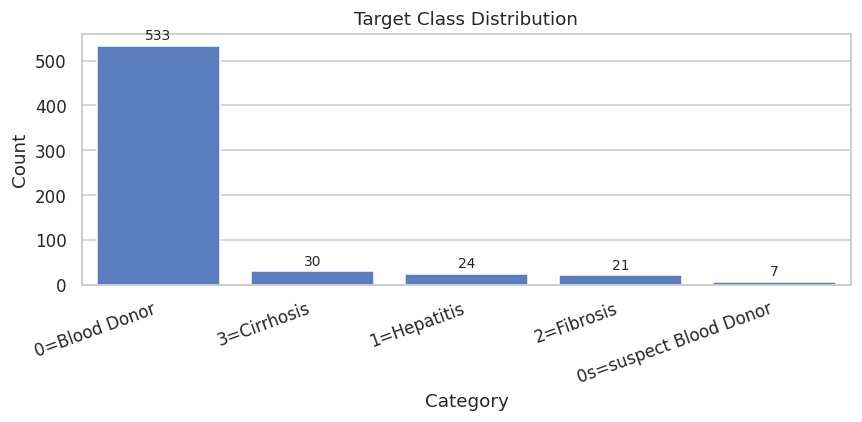


3. HISTOGRAMS OF NUMERICAL FEATURES


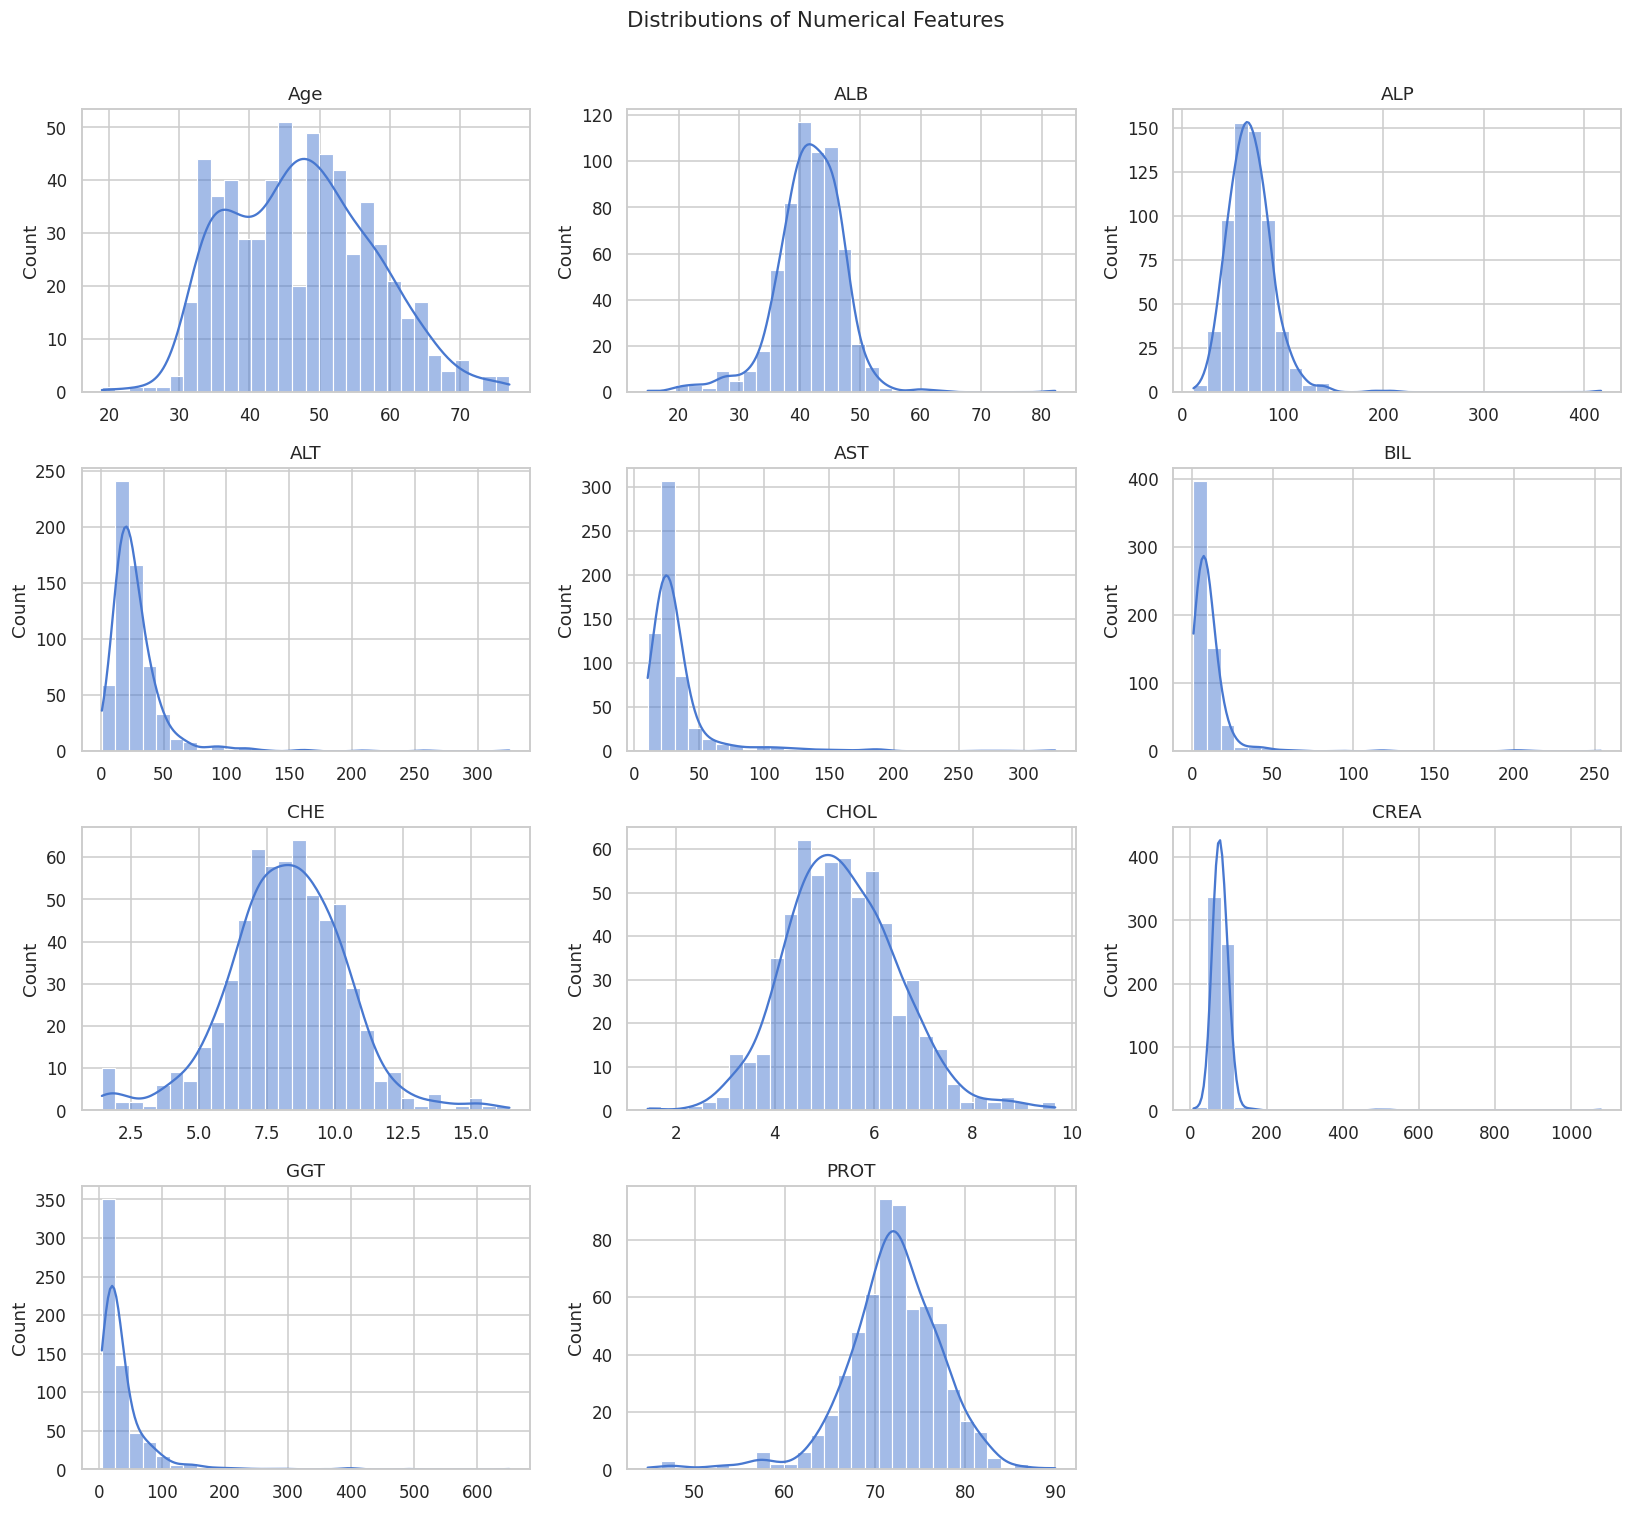


4. BOXPLOTS OF NUMERICAL FEATURES


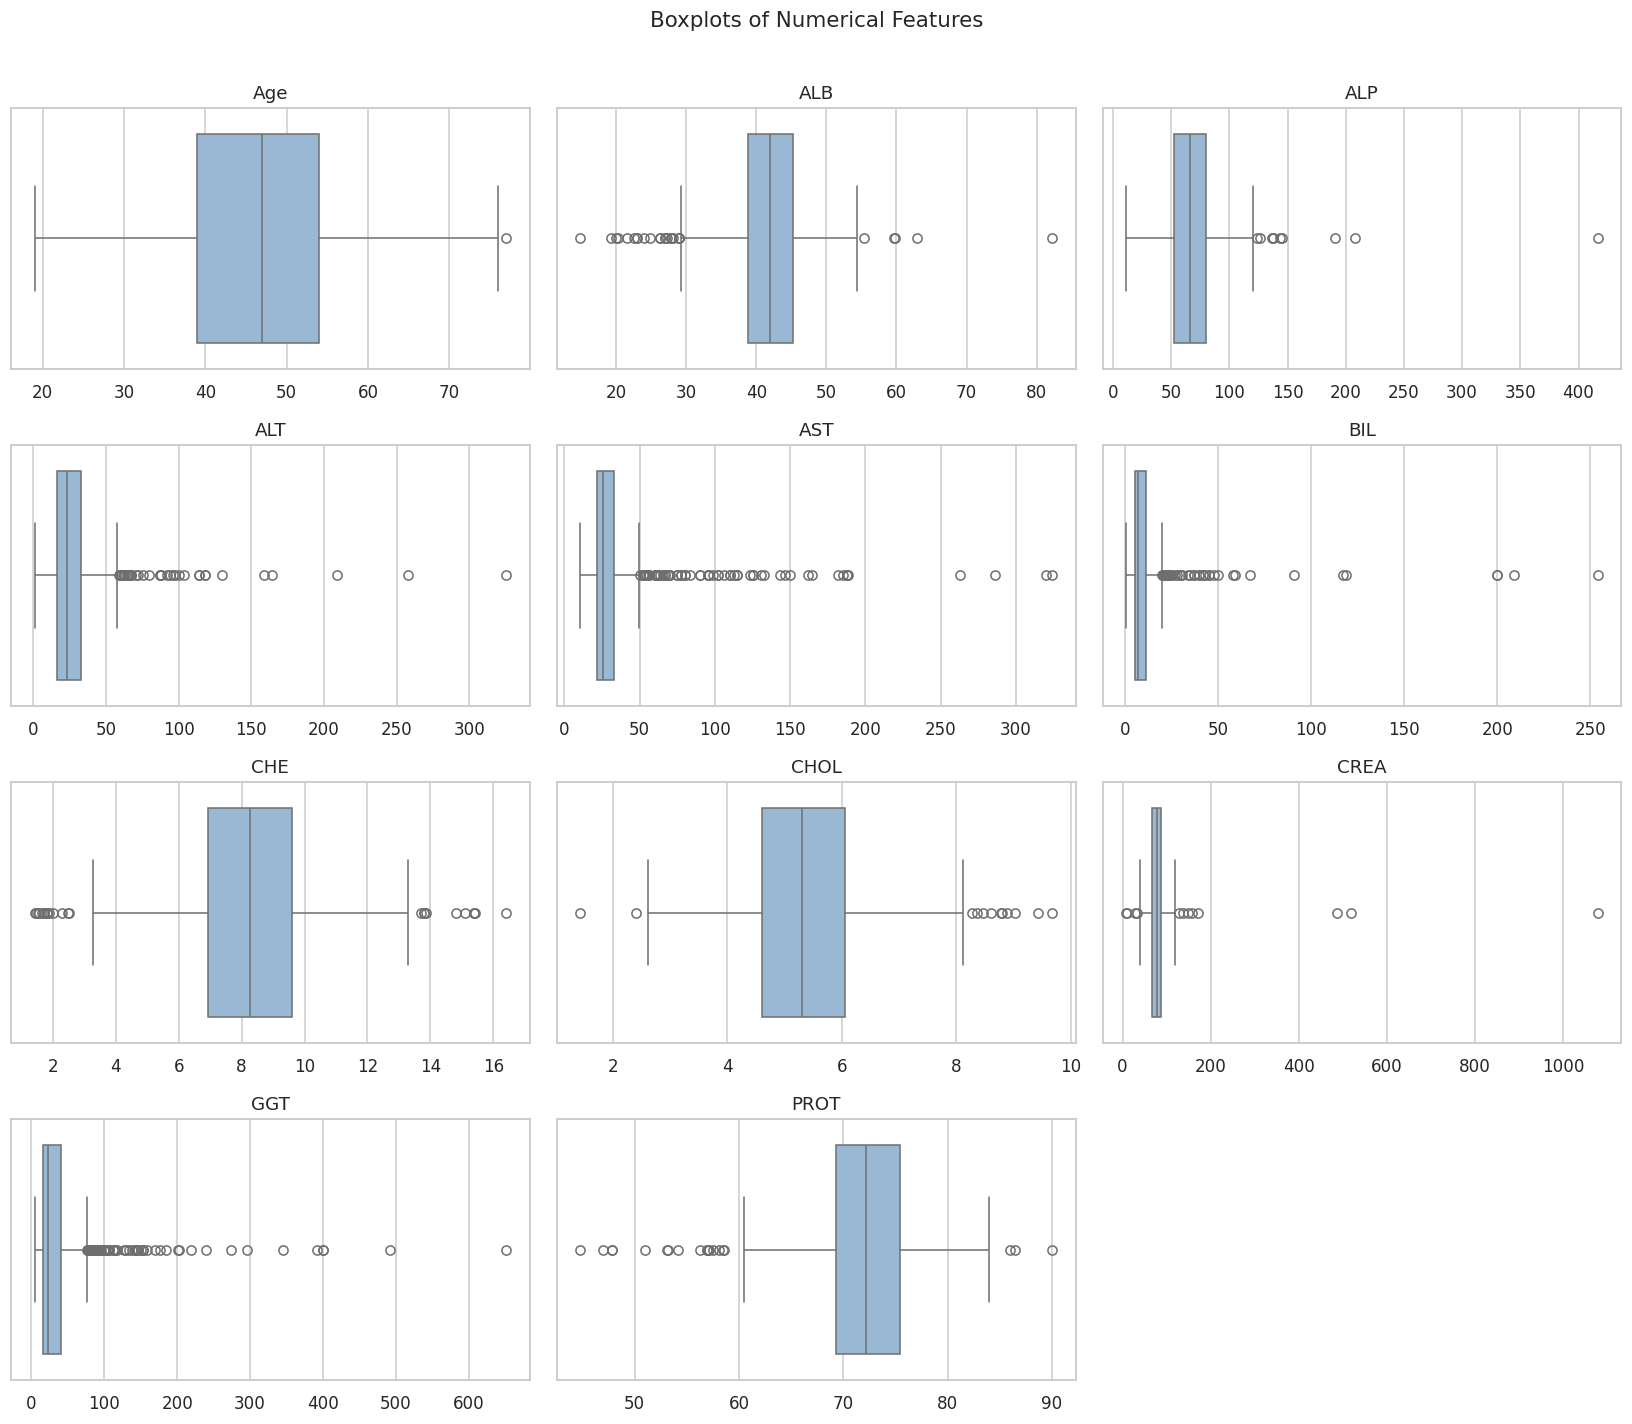


5. CORRELATION HEATMAP (PEARSON)
       Age   ALB   ALP   ALT   AST   BIL   CHE  CHOL  CREA   GGT  PROT
Age   1.00 -0.20  0.17 -0.01  0.09  0.03 -0.08  0.13 -0.02  0.15 -0.15
ALB  -0.20  1.00 -0.14  0.00 -0.19 -0.22  0.38  0.21 -0.00 -0.16  0.56
ALP   0.17 -0.14  1.00  0.21  0.06  0.06  0.03  0.13  0.15  0.45 -0.06
ALT  -0.01  0.00  0.21  1.00  0.27 -0.04  0.15  0.07 -0.04  0.25  0.09
AST   0.09 -0.19  0.06  0.27  1.00  0.31 -0.21 -0.21 -0.02  0.49  0.04
BIL   0.03 -0.22  0.06 -0.04  0.31  1.00 -0.33 -0.18  0.03  0.22 -0.05
CHE  -0.08  0.38  0.03  0.15 -0.21 -0.33  1.00  0.43 -0.01 -0.11  0.30
CHOL  0.13  0.21  0.13  0.07 -0.21 -0.18  0.43  1.00 -0.05 -0.01  0.21
CREA -0.02 -0.00  0.15 -0.04 -0.02  0.03 -0.01 -0.05  1.00  0.12 -0.03
GGT   0.15 -0.16  0.45  0.25  0.49  0.22 -0.11 -0.01  0.12  1.00 -0.01
PROT -0.15  0.56 -0.06  0.09  0.04 -0.05  0.30  0.21 -0.03 -0.01  1.00


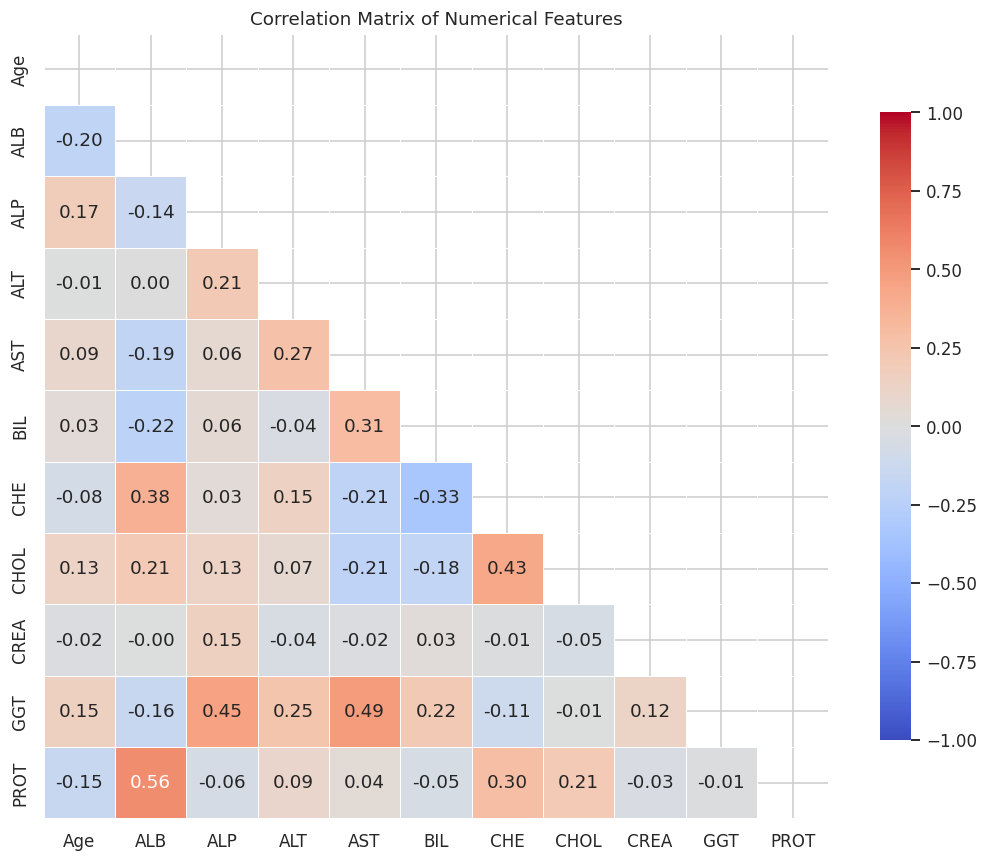


Top 10 strongest correlations (|r|):
ALB  PROT    0.557
AST  GGT     0.491
GGT  ALP     0.455
CHE  CHOL    0.425
ALB  CHE     0.376
BIL  CHE    -0.333
     AST     0.312
CHE  PROT    0.295
AST  ALT     0.273
ALT  GGT     0.248
dtype: float64

6. SKEWNESS OF NUMERICAL FEATURES
      skewness  abs_skew           interpretation
CREA    15.169    15.169            highly skewed
BIL      8.385     8.385            highly skewed
GGT      5.633     5.633            highly skewed
ALT      5.506     5.506            highly skewed
AST      4.940     4.940            highly skewed
ALP      4.655     4.655            highly skewed
PROT    -0.964     0.964        moderately skewed
CHOL     0.376     0.376  approximately symmetric
Age      0.267     0.267  approximately symmetric
ALB     -0.177     0.177  approximately symmetric
CHE     -0.110     0.110  approximately symmetric

7. CATEGORICAL FEATURE DISTRIBUTIONS

--- Sex ---
     count  percent
Sex                
m      377     61.3
f      238 

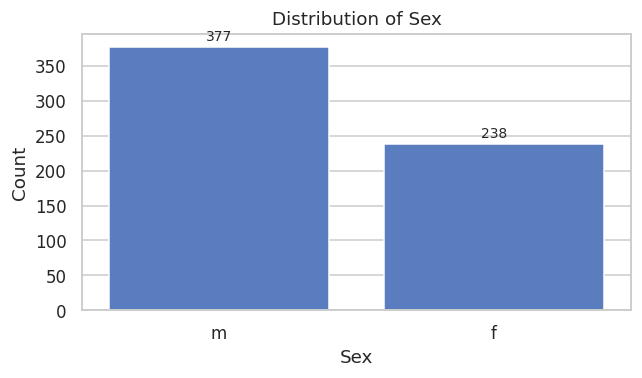


Sex vs Category (row percentages):
Category  0=Blood Donor  0s=suspect Blood Donor  1=Hepatitis  2=Fibrosis  3=Cirrhosis
Sex                                                                                  
f                  90.3                     0.4          1.7         3.4          4.2
m                  84.4                     1.6          5.3         3.4          5.3

8. NUMERICAL FEATURES BY CATEGORY


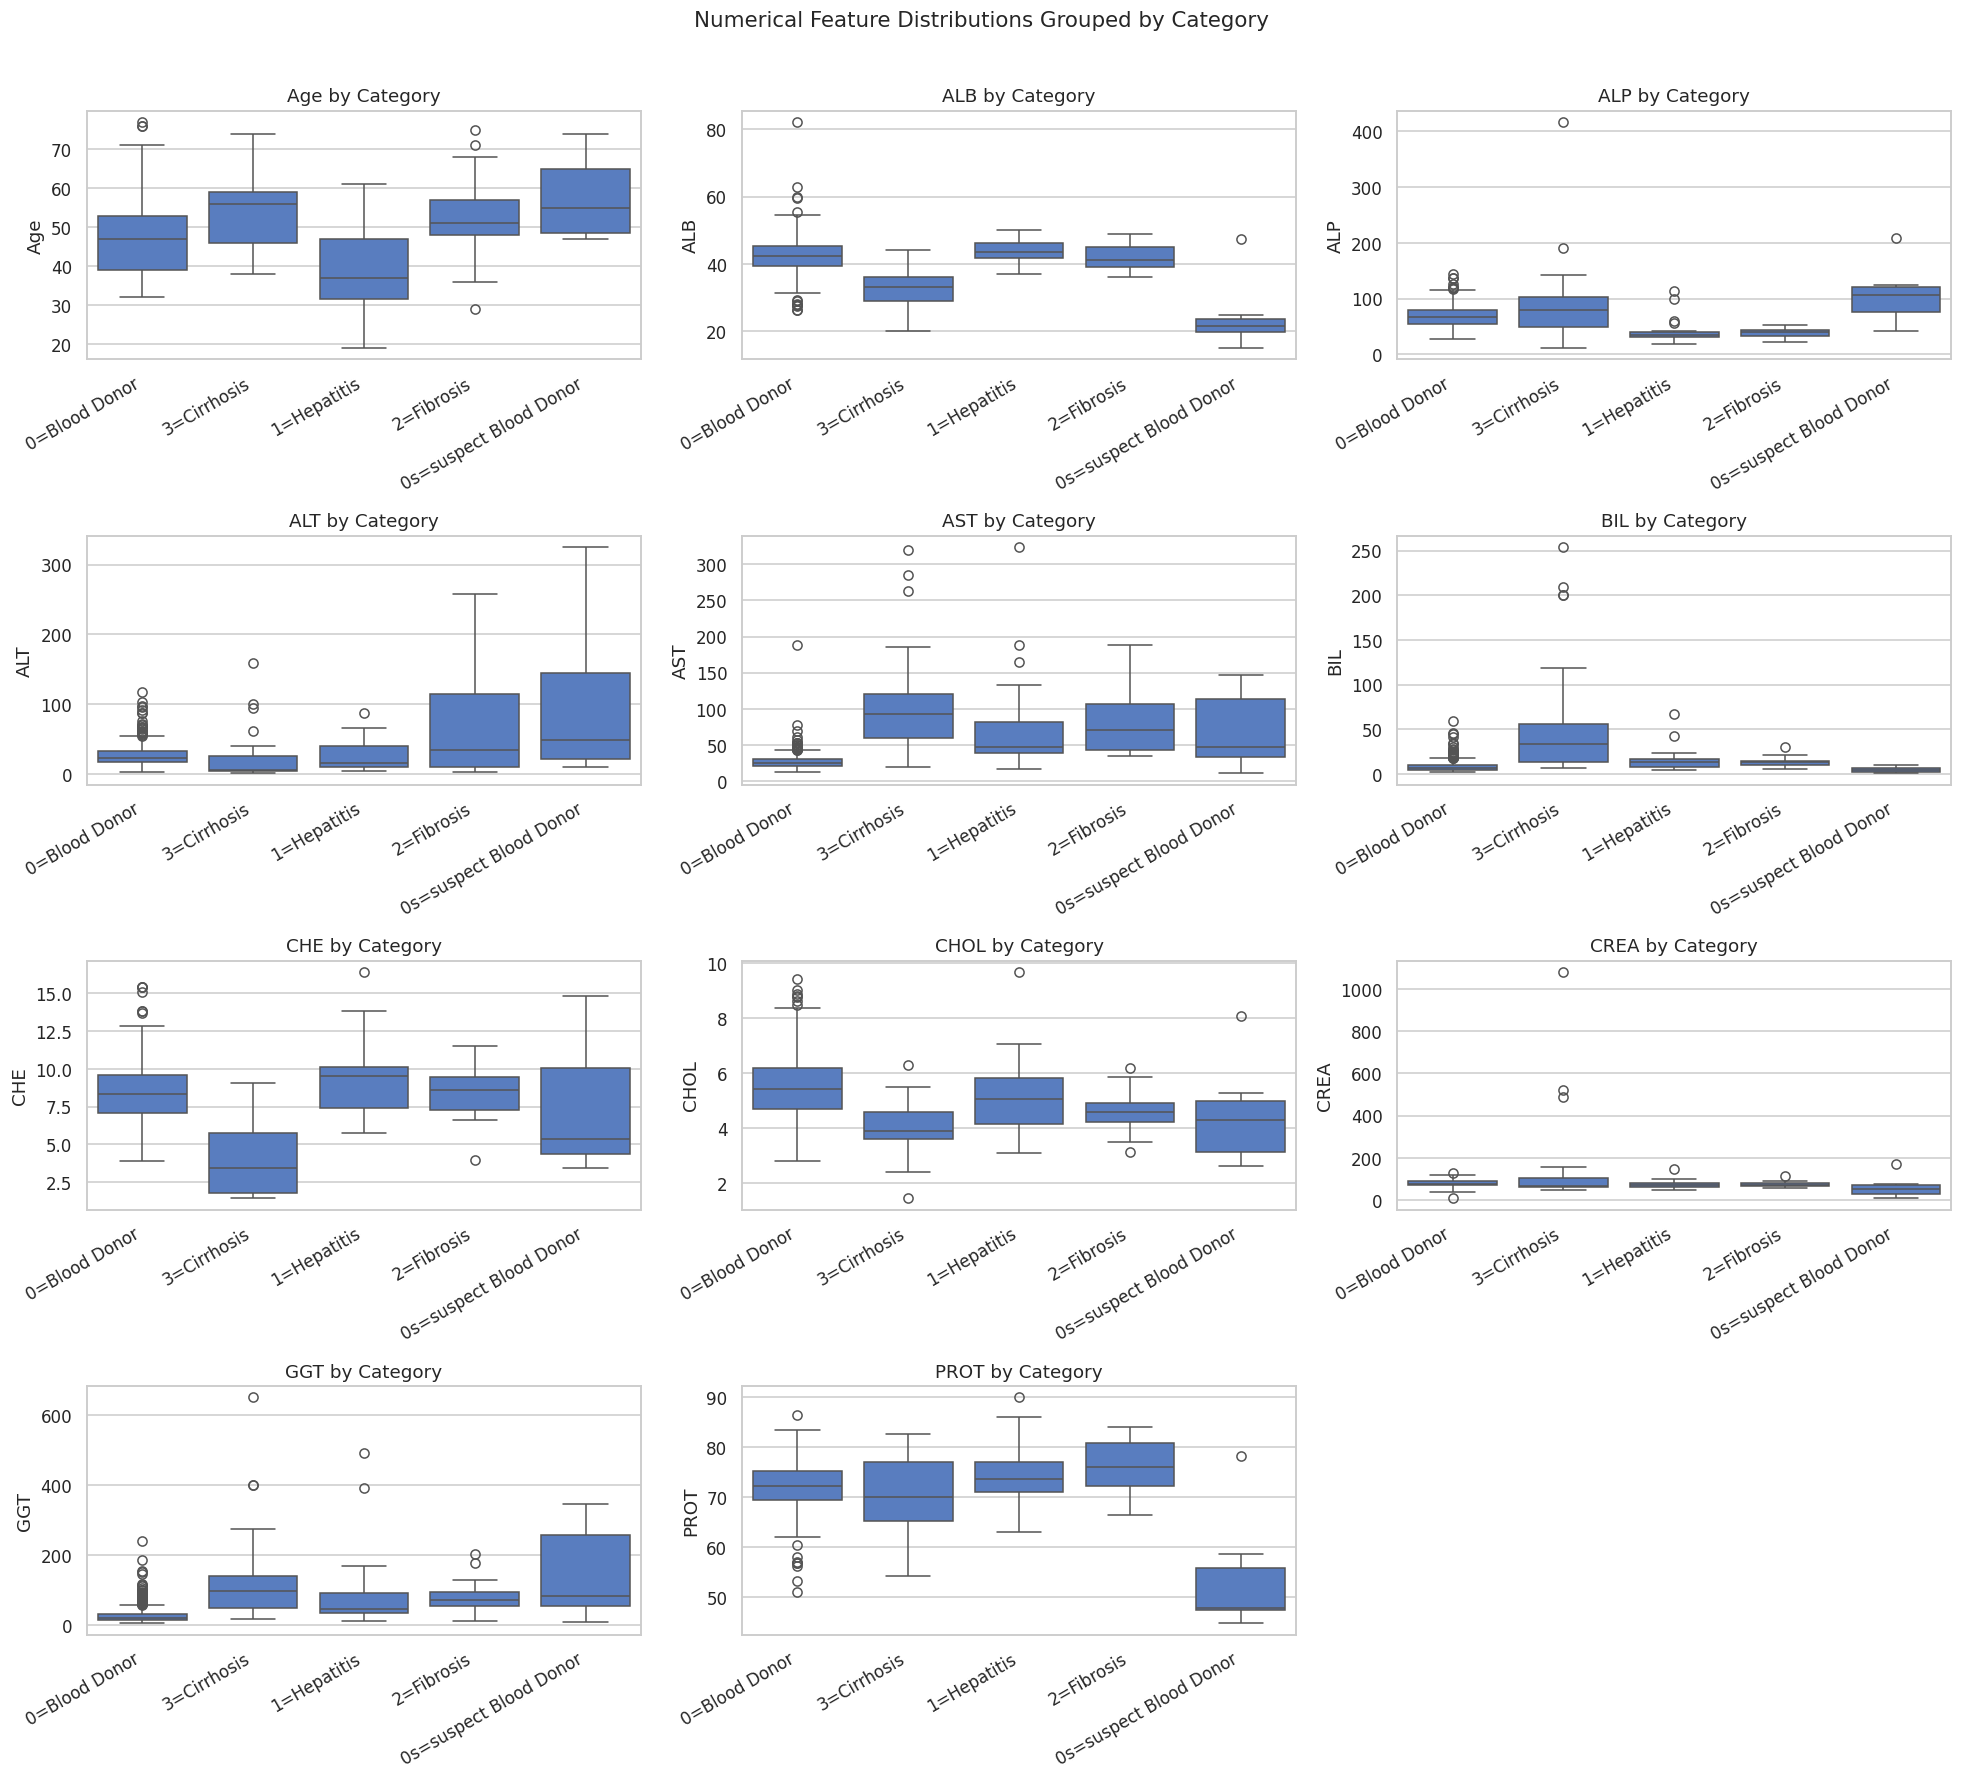


9. GROUP STATISTICS BY CATEGORY (MEAN / MEDIAN / STD)

--- Age ---
                         mean  median    std
Category                                    
0=Blood Donor           47.13    47.0   9.62
0s=suspect Blood Donor  57.57    55.0  11.07
1=Hepatitis             38.71    37.0  11.35
2=Fibrosis              52.33    51.0  11.44
3=Cirrhosis             53.47    56.0   8.91

--- ALB ---
                         mean  median    std
Category                                    
0=Blood Donor           42.24    42.2   5.03
0s=suspect Blood Donor  24.40    21.6  10.56
1=Hepatitis             43.83    43.5   3.51
2=Fibrosis              41.76    41.0   3.74
3=Cirrhosis             32.48    33.0   5.82

--- ALP ---
                          mean  median    std
Category                                     
0=Blood Donor            68.37   66.70  18.23
0s=suspect Blood Donor  107.30  106.00  52.82
1=Hepatitis              42.11   34.60  23.52
2=Fibrosis               37.84   39.55   8.31


In [27]:
# =============================================================================
# Hepatitis C Dataset — Step 2: Exploratory Data Analysis (Google Colab)
# Assumes `df` is already loaded from Step 1.
# The dataset is ONLY inspected and visualized — never modified.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Global display / plotting configuration ---------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


def section(title):
    """Print a clearly delimited section header."""
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# -----------------------------------------------------------------------------
# Feature groups
# -----------------------------------------------------------------------------
# 'Category' is the target. 'Unnamed: 0' is a row-index artifact from the CSV and
# carries no information, so it is excluded from analysis (but not dropped from df).
TARGET = "Category"
ID_LIKE = [c for c in df.columns if c.lower().startswith("unnamed")]

numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ID_LIKE
]
categorical_cols = [
    c for c in df.select_dtypes(include=["object", "category"]).columns
    if c != TARGET
]

print("Numerical features  :", numeric_cols)
print("Categorical features:", categorical_cols)
print("Target              :", TARGET)


# =============================================================================
# 1. DATASET OVERVIEW
# =============================================================================
section("1. Dataset overview")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

print("--- Data types ---")
print(df.dtypes, "\n")

print("--- Missing values ---")
missing = df.isnull().sum()
missing_tbl = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(df) * 100).round(2),
})
print(missing_tbl[missing_tbl.missing_count > 0].sort_values(
    "missing_count", ascending=False))
if missing.sum() == 0:
    print("No missing values.")
print()

print("--- Duplicate rows ---")
print(f"{df.duplicated().sum()} fully duplicated rows\n")

print("--- Numeric summary ---")
print(df[numeric_cols].describe().T)


# =============================================================================
# 2. TARGET CLASS DISTRIBUTION
# =============================================================================
section("2. Target class distribution")

target_counts = df[TARGET].value_counts(dropna=False)
target_pct = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)
target_tbl = pd.DataFrame({"count": target_counts, "percent": target_pct})
print(target_tbl)

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x=TARGET, order=target_counts.index)
ax.set_title("Target Class Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
plt.xticks(rotation=20, ha="right")
# Annotate each bar with its count
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)
plt.tight_layout()
plt.show()


# =============================================================================
# 3. NUMERICAL FEATURES — DISTRIBUTIONS (HISTOGRAMS)
# =============================================================================
section("3. Histograms of numerical features")

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.4 * n_rows))
axes = np.array(axes).ravel()

for ax, col in zip(axes, numeric_cols):
    # dropna() only affects the plotted series, not df itself
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

# Hide any unused subplot slots
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Distributions of Numerical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# 4. NUMERICAL FEATURES — BOXPLOTS (OUTLIER VIEW)
# =============================================================================
section("4. Boxplots of numerical features")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes = np.array(axes).ravel()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="#8fb8de")
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Boxplots of Numerical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# 5. CORRELATION HEATMAP
# =============================================================================
section("5. Correlation heatmap (Pearson)")

corr = df[numeric_cols].corr(numeric_only=True)
print(corr.round(2))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

# Highlight the strongest pairwise relationships
corr_pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))   # drop self-correlations
        .stack()
        .sort_values(key=abs, ascending=False)
)
print("\nTop 10 strongest correlations (|r|):")
print(corr_pairs.drop_duplicates().head(10).round(3))


# =============================================================================
# 6. SKEWNESS TABLE (SORTED)
# =============================================================================
section("6. Skewness of numerical features")

skew_tbl = (
    df[numeric_cols]
    .skew(numeric_only=True)
    .rename("skewness")
    .to_frame()
    .assign(abs_skew=lambda x: x.skewness.abs())
    .sort_values("abs_skew", ascending=False)
)
# Rule of thumb: |skew| < 0.5 symmetric, 0.5–1 moderate, > 1 high
skew_tbl["interpretation"] = pd.cut(
    skew_tbl["abs_skew"],
    bins=[-0.01, 0.5, 1.0, np.inf],
    labels=["approximately symmetric", "moderately skewed", "highly skewed"],
)
print(skew_tbl.round(3))


# =============================================================================
# 7. CATEGORICAL FEATURES — COUNT PLOTS
# =============================================================================
section("7. Categorical feature distributions")

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    print(f"\n--- {col} ---")
    print(pd.DataFrame({"count": counts, "percent": pct}))

    plt.figure(figsize=(6, 3.6))
    ax = sns.countplot(data=df, x=col, order=counts.index)
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Cross-tabulation against the target
    print(f"\n{col} vs {TARGET} (row percentages):")
    print(pd.crosstab(df[col], df[TARGET], normalize="index").mul(100).round(1))


# =============================================================================
# 8. NUMERICAL FEATURES GROUPED BY TARGET — BOXPLOTS
# =============================================================================
section("8. Numerical features by category")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).ravel()

cat_order = df[TARGET].value_counts().index

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x=TARGET, y=col, order=cat_order, ax=ax)
    ax.set_title(f"{col} by {TARGET}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Numerical Feature Distributions Grouped by Category",
             y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# 9. SUMMARY TABLE OF NUMERICAL FEATURES BY CATEGORY
# =============================================================================
section("9. Group statistics by category (mean / median / std)")

group_stats = df.groupby(TARGET, dropna=False)[numeric_cols].agg(
    ["mean", "median", "std"]
).round(2)

# Print one feature at a time — far more readable than a single wide table
for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(group_stats[col])


# =============================================================================
# 10. AUTOMATED OBSERVATIONS
# =============================================================================
section("10. Key observations")

# --- Class imbalance ---------------------------------------------------------
print("CLASS IMBALANCE")
majority, minority = target_counts.iloc[0], target_counts.iloc[-1]
imbalance_ratio = majority / minority
print(f"  Majority class : '{target_counts.index[0]}' "
      f"({majority} rows, {target_pct.iloc[0]}%)")
print(f"  Minority class : '{target_counts.index[-1]}' "
      f"({minority} rows, {target_pct.iloc[-1]}%)")
print(f"  Imbalance ratio: {imbalance_ratio:.1f} : 1")
if imbalance_ratio >= 10:
    print("  -> SEVERE imbalance. Use stratified splits, class weights, or "
          "resampling; accuracy alone will be misleading.")
elif imbalance_ratio >= 3:
    print("  -> Noticeable imbalance. Prefer stratified splits and "
          "macro-F1 / balanced accuracy over plain accuracy.")
else:
    print("  -> Classes are reasonably balanced.")

# --- Missing values ----------------------------------------------------------
print("\nMISSING VALUES")
cols_with_na = missing[missing > 0]
if cols_with_na.empty:
    print("  No missing values detected.")
else:
    for col, n in cols_with_na.sort_values(ascending=False).items():
        print(f"  {col:<8} {n:>3} missing ({n / len(df) * 100:.2f}%)")
    print("  -> All gaps are small; median or model-based imputation is "
          "appropriate at the cleaning stage (Step 3).")

# --- Skewed features ---------------------------------------------------------
print("\nSKEWED FEATURES (|skew| > 1)")
high_skew = skew_tbl[skew_tbl.abs_skew > 1]
if high_skew.empty:
    print("  None.")
else:
    for col, row in high_skew.iterrows():
        direction = "right" if row.skewness > 0 else "left"
        print(f"  {col:<8} skew = {row.skewness:>7.2f}  ({direction}-skewed)")
    print("  -> Consider log / Box-Cox / Yeo-Johnson transforms, or use "
          "tree-based models that are insensitive to skew.")

# --- Potential outliers (IQR rule) -------------------------------------------
print("\nPOTENTIAL OUTLIERS (values beyond 1.5 x IQR)")
outlier_rows = []
for col in numeric_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < low) | (s > high)).sum()
    outlier_rows.append({
        "feature": col,
        "n_outliers": int(n_out),
        "pct_outliers": round(n_out / len(s) * 100, 2),
        "lower_bound": round(low, 2),
        "upper_bound": round(high, 2),
    })

outlier_tbl = (pd.DataFrame(outlier_rows)
               .set_index("feature")
               .sort_values("n_outliers", ascending=False))
print(outlier_tbl)
print("  -> In clinical data, extreme lab values are often genuine disease "
       "signals rather than errors. Do NOT remove them blindly; inspect them "
       "against the target class first.")

print("\nEDA complete. Dataset left unmodified.")

In [28]:
# =============================================================================
# Step 3. Data Cleaning (corrected)
# Creates a clean working copy of the dataset. `df` remains unchanged.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("=" * 70)
print("STEP 3 — DATA CLEANING")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Working copy
# -----------------------------------------------------------------------------
data = df.copy()
print(f"\nOriginal shape: {data.shape}")

# -----------------------------------------------------------------------------
# 2. Remove technical index column
# -----------------------------------------------------------------------------
if "Unnamed: 0" in data.columns:
    data.drop(columns=["Unnamed: 0"], inplace=True)
    print("Removed: 'Unnamed: 0'")
print(f"Current shape: {data.shape}")

# -----------------------------------------------------------------------------
# 3. Column groups
# -----------------------------------------------------------------------------
TARGET = "Category"
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [
    c for c in data.select_dtypes(include=["object", "category"]).columns
    if c != TARGET
]

# Remember original dtypes so integer columns stay integers after imputation
original_dtypes = data[numeric_cols].dtypes.to_dict()

# -----------------------------------------------------------------------------
# 4. Missing values BEFORE imputation
# -----------------------------------------------------------------------------
def missing_report(frame, label):
    """Return a tidy missing-value table for the given dataframe."""
    m = frame.isna().sum().to_frame("Missing")
    m["Percent"] = (m["Missing"] / len(frame) * 100).round(2)
    m = m[m["Missing"] > 0].sort_values("Missing", ascending=False)
    print(f"\nMissing values {label}")
    print(m if not m.empty else "  None.")
    return m

missing_before = missing_report(data, "BEFORE imputation")

# Snapshot pre-imputation stats so we can verify the imputer behaved sensibly
cols_with_na = missing_before.index.tolist()
stats_before = data[cols_with_na].describe().T[["mean", "50%", "std"]] \
    if cols_with_na else None

# -----------------------------------------------------------------------------
# 5. KNN imputation on SCALED features
# -----------------------------------------------------------------------------
# KNNImputer uses Euclidean distance, so unscaled features with large ranges
# (CREA, ALP, AST, GGT) would dominate the neighbor search and make the
# imputations for small-range features (ALB, CHOL) effectively arbitrary.
# Fix: standardize -> impute -> invert the scaling.
#
# `Sex` is encoded and included so the neighbor search can use it, then dropped.
impute_frame = data[numeric_cols].copy()
if "Sex" in data.columns:
    impute_frame["Sex_enc"] = (data["Sex"] == "m").astype(float)

scaler = StandardScaler()
scaled = scaler.fit_transform(impute_frame)

imputer = KNNImputer(n_neighbors=5, weights="distance")
imputed_scaled = imputer.fit_transform(scaled)

# Back to original units, then keep only the real numeric columns
imputed = pd.DataFrame(
    scaler.inverse_transform(imputed_scaled),
    columns=impute_frame.columns,
    index=impute_frame.index,
)
data[numeric_cols] = imputed[numeric_cols]

# Restore integer dtypes (KNNImputer returns floats for the whole block)
for col, dtype in original_dtypes.items():
    if pd.api.types.is_integer_dtype(dtype):
        data[col] = data[col].round().astype(dtype)

# -----------------------------------------------------------------------------
# 6. Missing values AFTER imputation
# -----------------------------------------------------------------------------
missing_after = missing_report(data, "AFTER imputation")
if data[numeric_cols].isna().sum().sum() == 0:
    print("\nAll numerical missing values have been imputed.")

# Sanity check: imputation should not have shifted the distributions much
if cols_with_na:
    stats_after = data[cols_with_na].describe().T[["mean", "50%", "std"]]
    comparison = stats_before.join(stats_after, lsuffix="_before", rsuffix="_after")
    print("\nDistribution check (imputed columns, before vs after):")
    print(comparison.round(3))

# -----------------------------------------------------------------------------
# 7. Duplicates
# -----------------------------------------------------------------------------
duplicates = data.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates:
    print("  Inspect these before deciding to drop — with only 12 lab values,\n"
          "  two distinct patients can legitimately produce identical rows.")
    print(data[data.duplicated(keep=False)].sort_values(numeric_cols[:2]))

# -----------------------------------------------------------------------------
# 8. Final report
# -----------------------------------------------------------------------------
print("\nCleaning completed successfully.")
print(f"Final shape: {data.shape}")
print("\nDtypes:")
print(data.dtypes)


# =============================================================================
# NOTE ON LEAKAGE
# =============================================================================
# The code above fits the scaler and imputer on the FULL dataset, so information
# from rows that later land in your test set influences the training rows.
# For modeling, prefer fitting only on the training split. The cleanest way is
# to move imputation into a Pipeline and let cross-validation handle it:
#
#   from sklearn.pipeline import Pipeline
#   from sklearn.compose import ColumnTransformer
#
#   numeric_pipe = Pipeline([
#       ("scale",  StandardScaler()),
#       ("impute", KNNImputer(n_neighbors=5, weights="distance")),
#   ])
#   preprocessor = ColumnTransformer([
#       ("num", numeric_pipe, numeric_cols),
#       ("cat", OneHotEncoder(drop="first"), categorical_cols),
#   ])
#   model = Pipeline([("prep", preprocessor), ("clf", YourClassifier())])
#
# Then `model.fit(X_train, y_train)` refits the imputer on each training fold
# only. Keep `data` above for EDA and reporting; use the pipeline for modeling.

STEP 3 — DATA CLEANING

Original shape: (615, 14)
Removed: 'Unnamed: 0'
Current shape: (615, 13)

Missing values BEFORE imputation
      Missing  Percent
ALP        18     2.93
CHOL       10     1.63
ALB         1     0.16
ALT         1     0.16
PROT        1     0.16

Missing values AFTER imputation
  None.

All numerical missing values have been imputed.

Distribution check (imputed columns, before vs after):
      mean_before  50%_before  std_before  mean_after  50%_after  std_after
ALP        68.284       66.20      26.028      68.349       66.4     25.678
CHOL        5.368        5.30       1.133       5.373        5.3      1.128
ALB        41.620       41.95       5.781      41.618       41.9      5.776
ALT        28.451       23.00      25.470      28.478       23.0     25.458
PROT       72.044       72.20       5.403      72.034       72.2      5.404

Duplicate rows: 0

Cleaning completed successfully.
Final shape: (615, 13)

Dtypes:
Category     object
Age           int64
Sex 

In [29]:
import numpy as np
import pandas as pd

from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
    FunctionTransformer,
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Make every transformer emit a DataFrame instead of a bare ndarray.
# This keeps column names alive through the whole pipeline, which matters for
# feature-importance plots and for CatBoost/LightGBM diagnostics later.
set_config(transform_output="pandas")


def section(title):
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# =============================================================================
# 1. WORKING COPY
# =============================================================================
section("1. Working copy")

# NOTE ON PROVENANCE — WHY WE START FROM `df`, NOT `data`
# -------------------------------------------------------
# Step 3 produced `data` by fitting a KNNImputer on the FULL dataset. Every
# imputed cell in `data` therefore carries information from rows that will
# later land in the test set. Reusing `data` here would bake that leak into
# every model downstream, and no amount of correct pipeline construction after
# this point could undo it.
#
# The division of labour is:
#
#   Step 3  ->  EXPLORATORY ONLY. Its cleaned frame exists so you can inspect
#               distributions, count duplicates, and produce reports on a
#               complete table. It is a reporting artifact, never a model input.
#
#   Step 4  ->  MODELLING. Starts from the raw frame and delegates ALL fitted
#               preprocessing (imputation, scaling, encoding) to the pipeline,
#               which sklearn refits on each training fold.
#
# Consequence: `source` still contains the original 31 missing cells. That is
# intentional. They are filled inside the pipeline, after the split.
source = df.drop(columns=["Unnamed: 0"])
print("Source: raw `df` — imputation is delegated entirely to the pipeline")
print("        (`data` from Step 3 is exploratory output, not a model input)")

print(f"Shape: {source.shape}")
print(f"Missing cells carried forward: {int(source.isna().sum().sum())} "
      f"(to be imputed inside the pipeline, per fold)")


# =============================================================================
# 2. FEATURES / TARGET SPLIT
# =============================================================================
section("2. Features and target")

TARGET = "Category"

X = source.drop(columns=[TARGET])
y_raw = source[TARGET]

print(f"X: {X.shape}")
print(f"y: {y_raw.shape}")


# =============================================================================
# 3. TARGET ENCODING
# =============================================================================
section("3. Target encoding")

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# The class mapping is what you will need to interpret confusion matrices and
# per-class metrics later. Keep it around.
class_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print("Class mapping (label -> encoded):")
for name, code in class_mapping.items():
    print(f"  {code}  <-  {name}")

print("\nTarget distribution:")
dist = pd.DataFrame({
    "count": y_raw.value_counts(),
    "percent": y_raw.value_counts(normalize=True).mul(100).round(2),
})
dist["encoded"] = [class_mapping[i] for i in dist.index]
print(dist)

# Warn early: some classes are tiny, which constrains your CV strategy.
smallest = dist["count"].min()
print(f"\nSmallest class has {smallest} samples.")
if smallest < 10:
    print("  -> Stratified k-fold with k > {} will fail or produce empty folds."
          .format(smallest))
    print("  -> Use StratifiedKFold(n_splits<=3), or merge the rare classes, or")
    print("     collapse to a binary 'donor vs. disease' target for a first pass.")


# =============================================================================
# 4. FEATURE ENGINEERING (STATELESS)
# =============================================================================
section("4. Feature engineering")

# Biomarkers that Step 2 flagged as heavily right-skewed. log1p compresses the
# long tail without touching zeros (all of these are non-negative lab values).
SKEWED = ["ALT", "AST", "GGT", "BIL", "CREA", "ALP"]

# Fixed, clinically motivated age bands. These boundaries are HARD-CODED on
# purpose: deriving them from data quantiles would leak the test distribution
# into the training features.
AGE_BINS = [0, 35, 45, 55, 65, 120]
AGE_LABELS = ["<35", "35-45", "45-55", "55-65", "65+"]

EPS = 1e-6          # guards against division by zero
REPLACE_SKEWED = True   # drop the raw column once its log version exists


def engineer_features(X_in: pd.DataFrame) -> pd.DataFrame:
    """
    Row-wise clinical feature construction. Stateless: the output for any given
    row depends only on that row, so this can safely run before any train/test
    split without leaking information.

    Adds
    ----
    AST_ALT_ratio : the De Ritis ratio. >2 is classically suggestive of
                    alcoholic liver disease or advanced fibrosis; <1 is more
                    typical of viral hepatitis.
    GLOB          : globulin, derived as total protein minus albumin.
    ALB_GLOB_ratio: the A/G ratio. Falls as chronic liver disease progresses,
                    because synthetic albumin drops while globulins rise.
    AST_PLT-like  : not available (no platelet count in this dataset).
    log_<marker>  : log1p of each heavily skewed biomarker.
    AgeGroup      : coarse age band, treated as categorical downstream.
    """
    Xe = X_in.copy()

    # --- De Ritis ratio ---------------------------------------------------
    if {"AST", "ALT"}.issubset(Xe.columns):
        Xe["AST_ALT_ratio"] = Xe["AST"] / (Xe["ALT"] + EPS)

    # --- Albumin / Globulin ----------------------------------------------
    # Globulin is not measured directly. It is standard practice to derive it:
    #     globulin = total protein - albumin
    # Both PROT and ALB are in g/L here, so the subtraction is dimensionally OK.
    if {"PROT", "ALB"}.issubset(Xe.columns):
        Xe["GLOB"] = (Xe["PROT"] - Xe["ALB"]).clip(lower=0)
        Xe["ALB_GLOB_ratio"] = Xe["ALB"] / (Xe["GLOB"] + EPS)

    # --- Log transforms for skewed biomarkers -----------------------------
    for col in SKEWED:
        if col in Xe.columns:
            # clip(lower=0) protects log1p from any negative artifact left by
            # an upstream imputer; real lab values are never negative.
            Xe[f"log_{col}"] = np.log1p(Xe[col].clip(lower=0))

    if REPLACE_SKEWED:
        # A log transform is monotone, so keeping both versions of a column
        # injects near-perfect collinearity. That destabilises Logistic
        # Regression coefficients and inflates tree-based importance splits
        # across two redundant features. Keep only the log version.
        Xe = Xe.drop(columns=[c for c in SKEWED if c in Xe.columns])

    # --- Age bands --------------------------------------------------------
    if "Age" in Xe.columns:
        Xe["AgeGroup"] = pd.cut(
            Xe["Age"], bins=AGE_BINS, labels=AGE_LABELS, right=False
        ).astype(str)   # str keeps it a clean categorical for OneHotEncoder

    return Xe

# Define a named function for feature_names_out
def get_engineered_column_names(transformer, feature_names_in):
    # This function needs to be aware of the transformations performed by engineer_features
    # The simplest way to handle this for FunctionTransformer is to re-run
    # engineer_features on a dummy DataFrame to get the column names.
    dummy_df = pd.DataFrame(columns=feature_names_in)
    engineered_dummy = engineer_features(dummy_df)
    return np.array(engineered_dummy.columns)


# Run once on X purely to discover the resulting column names and dtypes.
# This inspects structure, not values, so it introduces no leakage.
X_engineered_preview = engineer_features(X)
ENGINEERED_COLUMNS = X_engineered_preview.columns.tolist()

new_features = [c for c in ENGINEERED_COLUMNS if c not in X.columns]
dropped_features = [c for c in X.columns if c not in ENGINEERED_COLUMNS]

print("Original features:")
print(f"  {X.columns.tolist()}")
print("\nEngineered (added):")
for c in new_features:
    print(f"  + {c}")
print("\nDropped (superseded by log versions):")
for c in dropped_features:
    print(f"  - {c}")
print(f"\nPost-engineering feature count: {len(ENGINEERED_COLUMNS)}")


# =============================================================================
# 5. COLUMN GROUPS
# =============================================================================
section("5. Numerical vs categorical features")

numeric_features = X_engineered_preview.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features = X_engineered_preview.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Numerical ({len(numeric_features)}):")
print(f"  {numeric_features}")
print(f"\nCategorical ({len(categorical_features)}):")
print(f"  {categorical_features}")

assert len(numeric_features) + len(categorical_features) == len(ENGINEERED_COLUMNS), \
    "Some column was classified as neither numeric nor categorical."


# =============================================================================
# 6. PREPROCESSING PIPELINE
# =============================================================================
section("6. Preprocessing pipeline")


def build_preprocessor(scale: bool = True) -> ColumnTransformer:
    """
    Build the ColumnTransformer.

    Parameters
    ----------
    scale : bool
        StandardScaler is required for Logistic Regression (and any distance-
        or gradient-based learner) but is pure overhead for Random Forest,
        XGBoost, LightGBM, and CatBoost, which split on rank rather than
        magnitude. Pass scale=False when building tree models.

    Every step here is FITTED, so it must live inside the pipeline: the
    imputation medians and the scaler's mean/std are learned from the training
    fold alone when the enclosing pipeline is fitted.

    WHY SimpleImputer(median) AND NOT KNNImputer
    --------------------------------------------
    Step 3 used KNN imputation. This pipeline deliberately does not, for four
    reasons:

    1. Volume. Only 31 cells out of 7,380 are missing (~0.4%), concentrated in
       ALP (18) and CHOL (10). At that density the choice of imputer moves
       essentially nothing downstream. Sophistication buys no accuracy.

    2. Fold size. Inside 5-fold CV each imputer is fitted on ~390 rows. A
       KNNImputer refits its neighbour search on every fold, on a shifting
       subset, which makes the imputed values themselves a source of
       fold-to-fold variance — noise added to an already noisy estimate on 615
       rows.

    3. Robustness. The median is unaffected by the extreme lab values (CREA,
       GGT, BIL) that Step 2 flagged. KNN distances are not, and correcting for
       that requires scaling *before* imputation, adding another fitted step
       and another chance to get the ordering wrong.

    4. Cost. KNNImputer is O(n^2) in the fit set and would be refitted 50 times
       under RepeatedStratifiedKFold, for no measurable gain.

    Median imputation here is a considered default, not a fallback. If you want
    to challenge it, swap in KNNImputer(n_neighbors=5) *inside this function*
    (after the scaler, so distances are on comparable scales) and compare CV
    scores — the pipeline structure makes that an honest comparison.

    Note on ordering: feature engineering runs BEFORE imputation, so a ratio
    built from a missing operand (e.g. AST_ALT_ratio when ALT is absent) is
    itself NaN and gets median-filled. With one such row in this dataset that
    is acceptable; the alternative — impute, then engineer — would build
    ratios out of fabricated values, which is arguably worse.
    """
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))

    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        # handle_unknown="ignore" means an unseen category at inference time
        # becomes an all-zero row rather than raising. Essential for a model
        # that will meet new patients.
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# The feature engineer is wrapped as a stateless transformer so it becomes the
# first stage of the pipeline. feature_names_out lets get_feature_names_out()
# resolve correctly through the whole chain.
feature_engineer = FunctionTransformer(
    engineer_features,
    validate=False,
    feature_names_out=get_engineered_column_names,
)


def build_preprocessing_pipeline(scale: bool = True) -> Pipeline:
    """Full preprocessing chain: engineer -> impute -> scale -> encode."""
    return Pipeline([
        ("engineer", feature_engineer),
        ("preprocess", build_preprocessor(scale=scale)),
    ])


preprocessor_linear = build_preprocessing_pipeline(scale=True)    # LogReg
preprocessor_tree = build_preprocessing_pipeline(scale=False)     # RF/XGB/LGBM/CatBoost

print(preprocessor_linear)


# =============================================================================
# 7. TRAIN / TEST SPLIT
# =============================================================================
section("7. Stratified split")

# Stratify so the rare hepatitis classes appear on both sides of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print("\nClass balance preserved across the split:")
split_check = pd.DataFrame({
    "train_pct": pd.Series(y_train).value_counts(normalize=True).mul(100).round(1),
    "test_pct": pd.Series(y_test).value_counts(normalize=True).mul(100).round(1),
}).sort_index()
split_check.index = [label_encoder.classes_[i] for i in split_check.index]
print(split_check)


# =============================================================================
# 8. FIT ON TRAIN ONLY — VERIFICATION
# =============================================================================
section("8. Verification")

# This fit is illustrative. In practice you attach a classifier to the pipeline
# and call fit once; cross_val_score / GridSearchCV then refit the preprocessor
# on every fold, which is precisely what prevents leakage.
X_train_proc = preprocessor_linear.fit_transform(X_train)
X_test_proc = preprocessor_linear.transform(X_test)   # transform only, never fit

print(f"Processed train: {X_train_proc.shape}")
print(f"Processed test : {X_test_proc.shape}")

final_names = preprocessor_linear.get_feature_names_out()
print(f"\nFinal feature names ({len(final_names)}):")
print(f"  {list(final_names)}")

print("\nSanity check — scaler was fitted on train only:")
print(f"  train mean (should be ~0): {X_train_proc[numeric_features].mean().mean():.6f}")
print(f"  test  mean (should NOT be 0): {X_test_proc[numeric_features].mean().mean():.6f}")
print("  A test mean of exactly 0 would mean the scaler saw the test set.")

print("\nNo NaNs remaining:", not X_train_proc.isna().any().any())


# =============================================================================
# 9. READY FOR MODELING
# =============================================================================
section("9. Usage")

print("""
Attach any estimator as the final step. The preprocessor refits on each
training fold automatically, so cross-validation scores stay honest:

    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score, StratifiedKFold

    model = Pipeline([
        ("prep", build_preprocessing_pipeline(scale=True)),
        ("clf",  LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")

For trees, skip the scaler:

    from xgboost import XGBClassifier

    model = Pipeline([
        ("prep", build_preprocessing_pipeline(scale=False)),
        ("clf",  XGBClassifier(objective="multi:softprob",
                               num_class=len(label_encoder.classes_),
                               eval_metric="mlogloss")),
    ])

Use scoring="f1_macro" or "balanced_accuracy", never plain accuracy: the
majority class alone would score ~87%.
""")

print("Objects exported: X, y, X_train, X_test, y_train, y_test,")
print("                  label_encoder, class_mapping,")
print("                  build_preprocessing_pipeline()")


1. WORKING COPY
Source: raw `df` — imputation is delegated entirely to the pipeline
        (`data` from Step 3 is exploratory output, not a model input)
Shape: (615, 13)
Missing cells carried forward: 31 (to be imputed inside the pipeline, per fold)

2. FEATURES AND TARGET
X: (615, 12)
y: (615,)

3. TARGET ENCODING
Class mapping (label -> encoded):
  0  <-  0=Blood Donor
  1  <-  0s=suspect Blood Donor
  2  <-  1=Hepatitis
  3  <-  2=Fibrosis
  4  <-  3=Cirrhosis

Target distribution:
                        count  percent  encoded
Category                                       
0=Blood Donor             533    86.67        0
3=Cirrhosis                30     4.88        4
1=Hepatitis                24     3.90        2
2=Fibrosis                 21     3.41        3
0s=suspect Blood Donor      7     1.14        1

Smallest class has 7 samples.
  -> Stratified k-fold with k > 7 will fail or produce empty folds.
  -> Use StratifiedKFold(n_splits<=3), or merge the rare classes, or
    

In [30]:
import numpy as np
import pandas as pd

from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
    FunctionTransformer,
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Make every transformer emit a DataFrame instead of a bare ndarray.
# This keeps column names alive through the whole pipeline, which matters for
# feature-importance plots and for CatBoost/LightGBM diagnostics later.
set_config(transform_output="pandas")


def section(title):
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# =============================================================================
# 1. WORKING COPY
# =============================================================================
section("1. Working copy")

# NOTE ON PROVENANCE — WHY WE START FROM `df`, NOT `data`
# -------------------------------------------------------
# Step 3 produced `data` by fitting a KNNImputer on the FULL dataset. Every
# imputed cell in `data` therefore carries information from rows that will
# later land in the test set. Reusing `data` here would bake that leak into
# every model downstream, and no amount of correct pipeline construction after
# this point could undo it.
#
# The division of labour is:
#
#   Step 3  ->  EXPLORATORY ONLY. Its cleaned frame exists so you can inspect
#               distributions, count duplicates, and produce reports on a
#               complete table. It is a reporting artifact, never a model input.
#
#   Step 4  ->  MODELLING. Starts from the raw frame and delegates ALL fitted
#               preprocessing (imputation, scaling, encoding) to the pipeline,
#               which sklearn refits on each training fold.
#
# Consequence: `source` still contains the original 31 missing cells. That is
# intentional. They are filled inside the pipeline, after the split.
source = df.drop(columns=["Unnamed: 0"])
print("Source: raw `df` — imputation is delegated entirely to the pipeline")
print("        (`data` from Step 3 is exploratory output, not a model input)")

print(f"Shape: {source.shape}")
print(f"Missing cells carried forward: {int(source.isna().sum().sum())} "
      f"(to be imputed inside the pipeline, per fold)")


# =============================================================================
# 2. FEATURES / TARGET SPLIT
# =============================================================================
section("2. Features and target")

TARGET = "Category"

X = source.drop(columns=[TARGET])
y_raw = source[TARGET]

print(f"X: {X.shape}")
print(f"y: {y_raw.shape}")


# =============================================================================
# 3. TARGET ENCODING
# =============================================================================
section("3. Target encoding")

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# The class mapping is what you will need to interpret confusion matrices and
# per-class metrics later. Keep it around.
class_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print("Class mapping (label -> encoded):")
for name, code in class_mapping.items():
    print(f"  {code}  <-  {name}")

print("\nTarget distribution:")
dist = pd.DataFrame({
    "count": y_raw.value_counts(),
    "percent": y_raw.value_counts(normalize=True).mul(100).round(2),
})
dist["encoded"] = [class_mapping[i] for i in dist.index]
print(dist)

# Warn early: some classes are tiny, which constrains your CV strategy.
smallest = dist["count"].min()
print(f"\nSmallest class has {smallest} samples.")
if smallest < 10:
    print("  -> Stratified k-fold with k > {} will fail or produce empty folds."
          .format(smallest))
    print("  -> Use StratifiedKFold(n_splits<=3), or merge the rare classes, or")
    print("     collapse to a binary 'donor vs. disease' target for a first pass.")


# =============================================================================
# 4. FEATURE ENGINEERING (STATELESS)
# =============================================================================
section("4. Feature engineering")

# Biomarkers that Step 2 flagged as heavily right-skewed. log1p compresses the
# long tail without touching zeros (all of these are non-negative lab values).
SKEWED = ["ALT", "AST", "GGT", "BIL", "CREA", "ALP"]

# Fixed, clinically motivated age bands. These boundaries are HARD-CODED on
# purpose: deriving them from data quantiles would leak the test distribution
# into the training features.
AGE_BINS = [0, 35, 45, 55, 65, 120]
AGE_LABELS = ["<35", "35-45", "45-55", "55-65", "65+"]

EPS = 1e-6          # guards against division by zero
REPLACE_SKEWED = True   # drop the raw column once its log version exists


def engineer_features(X_in: pd.DataFrame) -> pd.DataFrame:
    """
    Row-wise clinical feature construction. Stateless: the output for any given
    row depends only on that row, so this can safely run before any train/test
    split without leaking information.

    Adds
    ----
    AST_ALT_ratio : the De Ritis ratio. >2 is classically suggestive of
                    alcoholic liver disease or advanced fibrosis; <1 is more
                    typical of viral hepatitis.
    GLOB          : globulin, derived as total protein minus albumin.
    ALB_GLOB_ratio: the A/G ratio. Falls as chronic liver disease progresses,
                    because synthetic albumin drops while globulins rise.
    AST_PLT-like  : not available (no platelet count in this dataset).
    log_<marker>  : log1p of each heavily skewed biomarker.
    AgeGroup      : coarse age band, treated as categorical downstream.
    """
    Xe = X_in.copy()

    # --- De Ritis ratio ---------------------------------------------------
    if {"AST", "ALT"}.issubset(Xe.columns):
        Xe["AST_ALT_ratio"] = Xe["AST"] / (Xe["ALT"] + EPS)

    # --- Albumin / Globulin ----------------------------------------------
    # Globulin is not measured directly. It is standard practice to derive it:
    #     globulin = total protein - albumin
    # Both PROT and ALB are in g/L here, so the subtraction is dimensionally OK.
    if {"PROT", "ALB"}.issubset(Xe.columns):
        Xe["GLOB"] = (Xe["PROT"] - Xe["ALB"]).clip(lower=0)
        Xe["ALB_GLOB_ratio"] = Xe["ALB"] / (Xe["GLOB"] + EPS)

    # --- Log transforms for skewed biomarkers -----------------------------
    for col in SKEWED:
        if col in Xe.columns:
            # clip(lower=0) protects log1p from any negative artifact left by
            # an upstream imputer; real lab values are never negative.
            Xe[f"log_{col}"] = np.log1p(Xe[col].clip(lower=0))

    if REPLACE_SKEWED:
        # A log transform is monotone, so keeping both versions of a column
        # injects near-perfect collinearity. That destabilises Logistic
        # Regression coefficients and inflates tree-based importance splits
        # across two redundant features. Keep only the log version.
        Xe = Xe.drop(columns=[c for c in SKEWED if c in Xe.columns])

    # --- Age bands --------------------------------------------------------
    if "Age" in Xe.columns:
        Xe["AgeGroup"] = pd.cut(
            Xe["Age"], bins=AGE_BINS, labels=AGE_LABELS, right=False
        ).astype(str)   # str keeps it a clean categorical for OneHotEncoder

    return Xe

# Define a named function for feature_names_out
def get_engineered_column_names(transformer, feature_names_in):
    # This function needs to be aware of the transformations performed by engineer_features
    # The simplest way to handle this for FunctionTransformer is to re-run
    # engineer_features on a dummy DataFrame to get the column names.
    dummy_df = pd.DataFrame(columns=feature_names_in)
    engineered_dummy = engineer_features(dummy_df)
    return np.array(engineered_dummy.columns)


# Run once on X purely to discover the resulting column names and dtypes.
# This inspects structure, not values, so it introduces no leakage.
X_engineered_preview = engineer_features(X)
ENGINEERED_COLUMNS = X_engineered_preview.columns.tolist()

new_features = [c for c in ENGINEERED_COLUMNS if c not in X.columns]
dropped_features = [c for c in X.columns if c not in ENGINEERED_COLUMNS]

print("Original features:")
print(f"  {X.columns.tolist()}")
print("\nEngineered (added):")
for c in new_features:
    print(f"  + {c}")
print("\nDropped (superseded by log versions):")
for c in dropped_features:
    print(f"  - {c}")
print(f"\nPost-engineering feature count: {len(ENGINEERED_COLUMNS)}")


# =============================================================================
# 5. COLUMN GROUPS
# =============================================================================
section("5. Numerical vs categorical features")

numeric_features = X_engineered_preview.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features = X_engineered_preview.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Numerical ({len(numeric_features)}):")
print(f"  {numeric_features}")
print(f"\nCategorical ({len(categorical_features)}):")
print(f"  {categorical_features}")

assert len(numeric_features) + len(categorical_features) == len(ENGINEERED_COLUMNS), \
    "Some column was classified as neither numeric nor categorical."


# =============================================================================
# 6. PREPROCESSING PIPELINE
# =============================================================================
section("6. Preprocessing pipeline")


def build_preprocessor(scale: bool = True) -> ColumnTransformer:
    """
    Build the ColumnTransformer.

    Parameters
    ----------
    scale : bool
        StandardScaler is required for Logistic Regression (and any distance-
        or gradient-based learner) but is pure overhead for Random Forest,
        XGBoost, LightGBM, and CatBoost, which split on rank rather than
        magnitude. Pass scale=False when building tree models.

    Every step here is FITTED, so it must live inside the pipeline: the
    imputation medians and the scaler's mean/std are learned from the training
    fold alone when the enclosing pipeline is fitted.

    WHY SimpleImputer(median) AND NOT KNNImputer
    --------------------------------------------
    Step 3 used KNN imputation. This pipeline deliberately does not, for four
    reasons:

    1. Volume. Only 31 cells out of 7,380 are missing (~0.4%), concentrated in
       ALP (18) and CHOL (10). At that density the choice of imputer moves
       essentially nothing downstream. Sophistication buys no accuracy.

    2. Fold size. Inside 5-fold CV each imputer is fitted on ~390 rows. A
       KNNImputer refits its neighbour search on every fold, on a shifting
       subset, which makes the imputed values themselves a source of
       fold-to-fold variance — noise added to an already noisy estimate on 615
       rows.

    3. Robustness. The median is unaffected by the extreme lab values (CREA,
       GGT, BIL) that Step 2 flagged. KNN distances are not, and correcting for
       that requires scaling *before* imputation, adding another fitted step
       and another chance to get the ordering wrong.

    4. Cost. KNNImputer is O(n^2) in the fit set and would be refitted 50 times
       under RepeatedStratifiedKFold, for no measurable gain.

    Median imputation here is a considered default, not a fallback. If you want
    to challenge it, swap in KNNImputer(n_neighbors=5) *inside this function*
    (after the scaler, so distances are on comparable scales) and compare CV
    scores — the pipeline structure makes that an honest comparison.

    Note on ordering: feature engineering runs BEFORE imputation, so a ratio
    built from a missing operand (e.g. AST_ALT_ratio when ALT is absent) is
    itself NaN and gets median-filled. With one such row in this dataset that
    is acceptable; the alternative — impute, then engineer — would build
    ratios out of fabricated values, which is arguably worse.
    """
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))

    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        # handle_unknown="ignore" means an unseen category at inference time
        # becomes an all-zero row rather than raising. Essential for a model
        # that will meet new patients.
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# The feature engineer is wrapped as a stateless transformer so it becomes the
# first stage of the pipeline. feature_names_out lets get_feature_names_out()
# resolve correctly through the whole chain.
feature_engineer = FunctionTransformer(
    engineer_features,
    validate=False,
    feature_names_out=get_engineered_column_names,
)


def build_preprocessing_pipeline(scale: bool = True) -> Pipeline:
    """Full preprocessing chain: engineer -> impute -> scale -> encode."""
    return Pipeline([
        ("engineer", feature_engineer),
        ("preprocess", build_preprocessor(scale=scale)),
    ])


preprocessor_linear = build_preprocessing_pipeline(scale=True)    # LogReg
preprocessor_tree = build_preprocessing_pipeline(scale=False)     # RF/XGB/LGBM/CatBoost

print(preprocessor_linear)


# =============================================================================
# 7. TRAIN / TEST SPLIT
# =============================================================================
section("7. Stratified split")

# Stratify so the rare hepatitis classes appear on both sides of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print("\nClass balance preserved across the split:")
split_check = pd.DataFrame({
    "train_pct": pd.Series(y_train).value_counts(normalize=True).mul(100).round(1),
    "test_pct": pd.Series(y_test).value_counts(normalize=True).mul(100).round(1),
}).sort_index()
split_check.index = [label_encoder.classes_[i] for i in split_check.index]
print(split_check)


# =============================================================================
# 8. FIT ON TRAIN ONLY — VERIFICATION
# =============================================================================
section("8. Verification")

# This fit is illustrative. In practice you attach a classifier to the pipeline
# and call fit once; cross_val_score / GridSearchCV then refit the preprocessor
# on every fold, which is precisely what prevents leakage.
X_train_proc = preprocessor_linear.fit_transform(X_train)
X_test_proc = preprocessor_linear.transform(X_test)   # transform only, never fit

print(f"Processed train: {X_train_proc.shape}")
print(f"Processed test : {X_test_proc.shape}")

final_names = preprocessor_linear.get_feature_names_out()
print(f"\nFinal feature names ({len(final_names)}):")
print(f"  {list(final_names)}")

print("\nSanity check — scaler was fitted on train only:")
print(f"  train mean (should be ~0): {X_train_proc[numeric_features].mean().mean():.6f}")
print(f"  test  mean (should NOT be 0): {X_test_proc[numeric_features].mean().mean():.6f}")
print("  A test mean of exactly 0 would mean the scaler saw the test set.")

print("\nNo NaNs remaining:", not X_train_proc.isna().any().any())


# =============================================================================
# 9. READY FOR MODELING
# =============================================================================
section("9. Usage")

print("""
Attach any estimator as the final step. The preprocessor refits on each
training fold automatically, so cross-validation scores stay honest:

    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score, StratifiedKFold

    model = Pipeline([
        ("prep", build_preprocessing_pipeline(scale=True)),
        ("clf",  LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")

For trees, skip the scaler:

    from xgboost import XGBClassifier

    model = Pipeline([
        ("prep", build_preprocessing_pipeline(scale=False)),
        ("clf",  XGBClassifier(objective="multi:softprob",
                               num_class=len(label_encoder.classes_),
                               eval_metric="mlogloss")),
    ])

Use scoring="f1_macro" or "balanced_accuracy", never plain accuracy: the
majority class alone would score ~87%.
""")

print("Objects exported: X, y, X_train, X_test, y_train, y_test,")
print("                  label_encoder, class_mapping,")
print("                  build_preprocessing_pipeline()")


1. WORKING COPY
Source: raw `df` — imputation is delegated entirely to the pipeline
        (`data` from Step 3 is exploratory output, not a model input)
Shape: (615, 13)
Missing cells carried forward: 31 (to be imputed inside the pipeline, per fold)

2. FEATURES AND TARGET
X: (615, 12)
y: (615,)

3. TARGET ENCODING
Class mapping (label -> encoded):
  0  <-  0=Blood Donor
  1  <-  0s=suspect Blood Donor
  2  <-  1=Hepatitis
  3  <-  2=Fibrosis
  4  <-  3=Cirrhosis

Target distribution:
                        count  percent  encoded
Category                                       
0=Blood Donor             533    86.67        0
3=Cirrhosis                30     4.88        4
1=Hepatitis                24     3.90        2
2=Fibrosis                 21     3.41        3
0s=suspect Blood Donor      7     1.14        1

Smallest class has 7 samples.
  -> Stratified k-fold with k > 7 will fail or produce empty folds.
  -> Use StratifiedKFold(n_splits<=3), or merge the rare classes, or
    


1. EXPERIMENTAL SETUP
Classes                : 5 -> ['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis']
Train / test           : 492 / 123 rows
Majority class share   : 86.6%
Trivial-baseline acc.  : 0.866  (predict majority always)
Trivial-baseline F1mac : 0.186

Cross-validation       : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
Primary metric         : f1_macro

Training-fold class counts (smallest class drives the fold count):
                        n_train  per_fold_approx
0=Blood Donor               426            142.0
0s=suspect Blood Donor        6              2.0
1=Hepatitis                  19              6.3
2=Fibrosis                   17              5.7
3=Cirrhosis                  24              8.0

2. CANDIDATE MODELS
CatBoost     : not installed -> skipped

Models entering the benchmark:
  Logistic Regression    scale=True
  Random Forest          scale=False
  XGBoost                scale=False
  LightGBM     

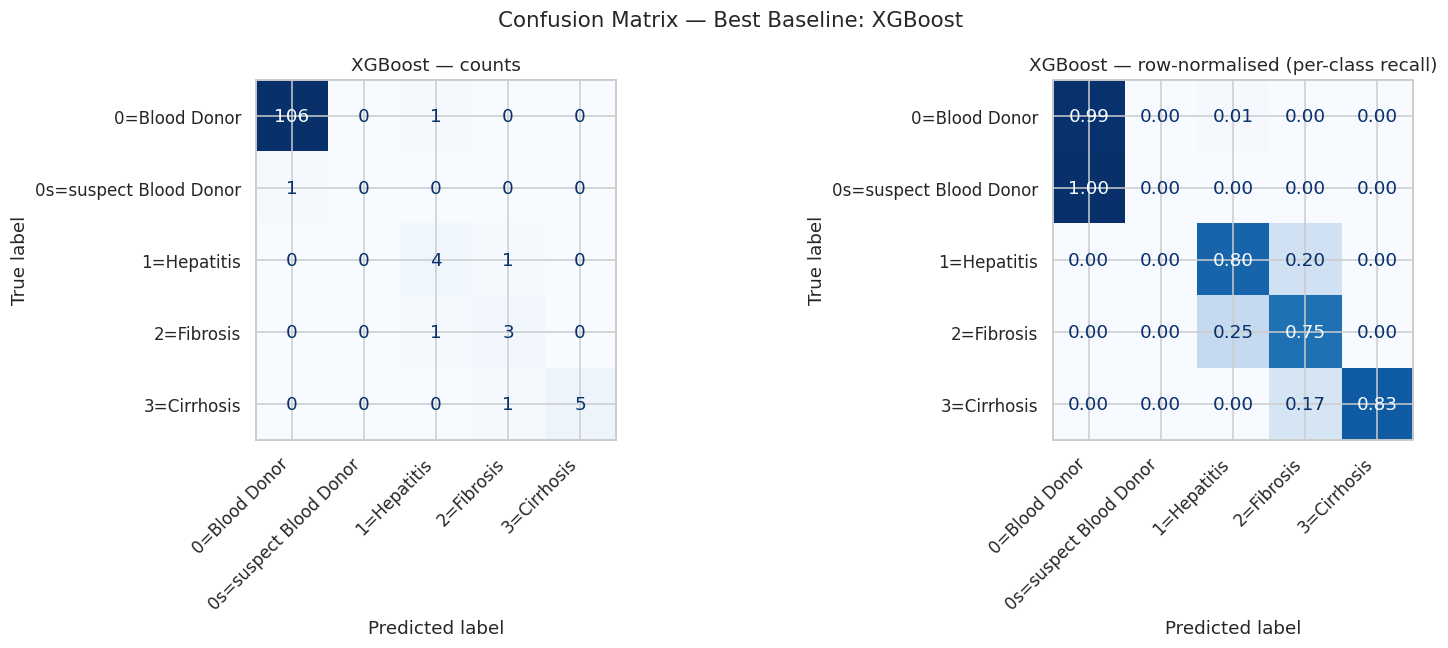

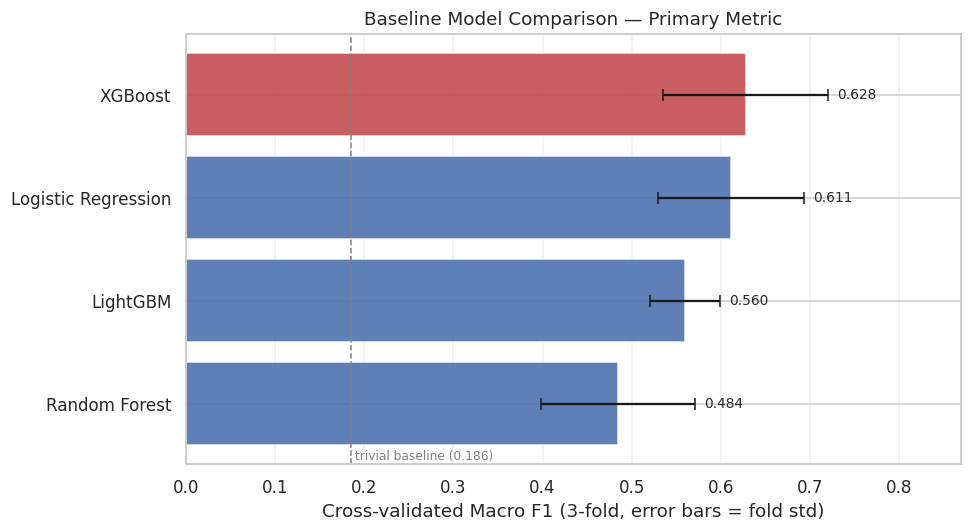


8. EXPORTS
best_model_name : XGBoost
best_model      : BalancedXGBClassifier (inside a fitted Pipeline)
results_df      : (4, 9) -> ranked benchmark table

Step 6 should tune `best_model_name`'s hyperparameters with
GridSearchCV / RandomizedSearchCV over the SAME pipeline object,
scoring='f1_macro', cv=StratifiedKFold(3). Because the preprocessing
lives inside the pipeline, the search refits it per fold automatically.


In [31]:
# =============================================================================
# Step 5. Model Training & Baseline Benchmark
#
# Consumes the exports from Step 4 and nothing else:
#     X_train, X_test, y_train, y_test
#     label_encoder, class_mapping
#     build_preprocessing_pipeline(scale=True/False)
#
# No preprocessing, feature engineering, or cleaning happens in this file.
# Every fitted transformation stays inside a Pipeline, so it is refitted on the
# training portion of each CV fold and never sees the held-out data.
#
# Exports: best_model, results_df  (for Step 6, Hyperparameter Tuning)
# =============================================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110


def section(title):
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# =============================================================================
# 0. COMPATIBILITY SHIM — FEATURE NAME SANITISATION
# =============================================================================
# Step 4 emits a one-hot column literally named `AgeGroup_<35`. XGBoost rejects
# any feature name containing '[', ']' or '<' and raises at fit time:
#
#     ValueError: feature_names must be string, and may not contain [, ] or <
#
# LightGBM historically raised a comparable error on special JSON characters.
# Rather than reach back and rewrite Step 4's age labels, this stateless
# transformer renames the columns *inside the pipeline*, immediately after
# preprocessing and before the estimator. It learns nothing from the data, so
# it introduces no leakage; it is a naming fix, not a transformation.
def _sanitize_names(X_in):
    """Strip characters that gradient-boosting libraries refuse to parse."""
    X_out = X_in.copy()
    X_out.columns = (
        pd.Index(X_out.columns)
        .str.replace(r"[\[\]<>]", "", regex=True)   # <35  -> 35
        .str.replace(r"[^0-9a-zA-Z_]", "_", regex=True)  # any residual junk
    )
    return X_out


sanitizer = FunctionTransformer(_sanitize_names, validate=False)


# =============================================================================
# 0b. CLASS-WEIGHTED XGBOOST
# =============================================================================
# sklearn estimators expose `class_weight="balanced"`. XGBoost does not: for
# multiclass problems it only accepts per-row `sample_weight` at fit time.
# Passing weights through cross_validate into a nested pipeline step is awkward,
# and — more importantly — the weights must be recomputed from the labels of
# each training fold, never from the full dataset.
#
# This subclass does exactly that: it derives the balanced sample weights from
# the `y` it is handed, which under cross-validation is the training fold alone.
try:
    from xgboost import XGBClassifier

    class BalancedXGBClassifier(XGBClassifier):
        """XGBClassifier with `class_weight='balanced'` semantics."""

        def fit(self, X, y, **kwargs):
            kwargs.setdefault(
                "sample_weight", compute_sample_weight("balanced", y)
            )
            return super().fit(X, y, **kwargs)

    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False


# =============================================================================
# 1. EXPERIMENTAL SETUP
# =============================================================================
section("1. Experimental setup")

RANDOM_STATE = 42
N_CLASSES = len(label_encoder.classes_)
CLASS_NAMES = list(label_encoder.classes_)

# --- Why 3 folds -------------------------------------------------------------
# The rarest class ('0s=suspect Blood Donor') contributes ~6 rows to X_train.
# StratifiedKFold guarantees each fold receives at least one member of every
# class, but with k=5 that means one or two rows per fold: the per-class recall
# for that class becomes a coin flip and the macro average inherits the noise.
# k=3 leaves ~2 rows per fold. This is not a comfortable number either — it is
# the least uncomfortable one available, and the reason every result below is
# reported with a standard deviation.
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Why F1 Macro is the primary metric --------------------------------------
# The majority class is 86.7% of the data. A classifier that predicts
# '0=Blood Donor' unconditionally scores ~0.87 accuracy while detecting exactly
# zero cases of hepatitis, fibrosis, or cirrhosis — a clinically worthless model
# with an impressive-looking number.
#
#   F1 Macro           averages the per-class F1 with EQUAL weight, so the 21
#                      fibrosis cases count as much as the 533 donors. This is
#                      the PRIMARY metric and the basis for model selection.
#   Balanced Accuracy  the mean per-class recall. Secondary; it rewards finding
#                      the sick but ignores false-alarm cost.
#   Accuracy           reported ONLY as a baseline-sanity reference. It is
#                      structurally misleading here and is never used to rank.
PRIMARY_METRIC = "f1_macro"
SCORING = {
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

majority_share = pd.Series(y_train).value_counts(normalize=True).max()
print(f"Classes                : {N_CLASSES} -> {CLASS_NAMES}")
print(f"Train / test           : {X_train.shape[0]} / {X_test.shape[0]} rows")
print(f"Majority class share   : {majority_share:.1%}")
print(f"Trivial-baseline acc.  : {majority_share:.3f}  (predict majority always)")
print(f"Trivial-baseline F1mac : {(2 * majority_share / (1 + majority_share)) / N_CLASSES:.3f}")
print(f"\nCross-validation       : {CV}")
print(f"Primary metric         : {PRIMARY_METRIC}")

print("\nTraining-fold class counts (smallest class drives the fold count):")
train_counts = pd.Series(y_train).value_counts().sort_index()
train_counts.index = CLASS_NAMES
print(pd.DataFrame({
    "n_train": train_counts,
    "per_fold_approx": (train_counts / CV.get_n_splits()).round(1),
}))


# =============================================================================
# 2. MODEL ZOO
# =============================================================================
section("2. Candidate models")

# Each entry: (name, estimator, needs_scaling)
#
# `needs_scaling` controls which preprocessing variant is attached. Logistic
# Regression optimises a distance-like objective and its L2 penalty is applied
# uniformly across coefficients, so unscaled features would be penalised in
# proportion to their units — CREA (hundreds) would be crushed while CHE
# (single digits) ran free. Tree ensembles split on rank order, which is
# invariant to any monotone rescaling, so a scaler there is pure overhead.
#
# `class_weight='balanced'` (or its per-library equivalent) is applied
# everywhere. Without it the 21 fibrosis cases are simply predicted away: the
# loss barely notices 21 misclassifications against 533 correct donors.
model_specs = []

# --- Linear baseline ---------------------------------------------------------
# The reference point. If a gradient-boosted ensemble cannot beat a regularised
# linear model on 615 rows, the ensemble is fitting noise.
model_specs.append((
    "Logistic Regression",
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    True,   # scale
))

# --- Bagged trees ------------------------------------------------------------
# `class_weight="balanced_subsample"` recomputes weights per bootstrap sample,
# which matters when a bootstrap draw happens to miss the rare classes entirely.
model_specs.append((
    "Random Forest",
    RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    False,  # no scale
))

# --- Boosted trees (optional dependencies) -----------------------------------
# Each import is guarded. A missing library degrades the benchmark, it does not
# break it.
if XGB_AVAILABLE:
    model_specs.append((
        "XGBoost",
        BalancedXGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,          # shallow: 615 rows will not support deep trees
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=N_CLASSES,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        False,
    ))
else:
    print("XGBoost      : not installed -> skipped")

try:
    from lightgbm import LGBMClassifier

    model_specs.append((
        "LightGBM",
        LGBMClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            num_leaves=15,        # < 2**max_depth, to keep trees genuinely small
            min_child_samples=5,  # default 20 would refuse to isolate rare classes
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        False,
    ))
except ImportError:
    print("LightGBM     : not installed -> skipped")

try:
    from catboost import CatBoostClassifier

    model_specs.append((
        "CatBoost",
        CatBoostClassifier(
            iterations=400,
            learning_rate=0.05,
            depth=4,
            loss_function="MultiClass",
            auto_class_weights="Balanced",   # CatBoost's own balancing switch
            random_seed=RANDOM_STATE,
            verbose=0,
            allow_writing_files=False,       # keeps Colab's filesystem clean
        ),
        False,
    ))
except ImportError:
    print("CatBoost     : not installed -> skipped")


def build_model_pipeline(estimator, scale: bool) -> Pipeline:
    """
    Assemble the full train-time pipeline for one estimator.

        engineer -> impute -> [scale] -> one-hot   (from Step 4)
        -> sanitise feature names                  (compatibility shim)
        -> estimator

    Because every fitted transformer sits inside this object, calling
    `cross_validate` on it refits the imputer, the scaler, and the one-hot
    vocabulary on each training fold in isolation. The validation fold is only
    ever passed through `transform`. This is the entire leakage guarantee.
    """
    return Pipeline([
        ("prep", build_preprocessing_pipeline(scale=scale)),
        ("sanitize", sanitizer),
        ("clf", estimator),
    ])


print("\nModels entering the benchmark:")
for name, _, scale in model_specs:
    print(f"  {name:<22} scale={scale}")


# =============================================================================
# 3. CROSS-VALIDATION
# =============================================================================
section("3. Cross-validation on X_train")

print("X_test is not touched anywhere in this section.\n")

cv_results = {}

for name, estimator, scale in model_specs:
    pipe = build_model_pipeline(estimator, scale)

    with warnings.catch_warnings():
        # Rare classes can produce empty predicted sets in a fold, which makes
        # sklearn warn about undefined precision. The zero-division behaviour is
        # the documented default (0.0) and is what we want; the warning is noise.
        warnings.simplefilter("ignore")
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=CV,
            scoring=SCORING,
            n_jobs=1,          # the estimators already parallelise internally
            error_score="raise",
        )

    cv_results[name] = {
        "cv_f1_macro": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
        "cv_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),
        "fit_time_s": scores["fit_time"].mean(),
    }

    print(f"{name:<22} "
          f"F1 macro {scores['test_f1_macro'].mean():.4f} "
          f"(+/- {scores['test_f1_macro'].std():.4f})   "
          f"bal.acc {scores['test_balanced_accuracy'].mean():.4f}   "
          f"acc {scores['test_accuracy'].mean():.4f}   "
          f"[{scores['fit_time'].mean():.2f}s]")


# =============================================================================
# 4. FINAL EVALUATION ON THE HELD-OUT TEST SET
# =============================================================================
section("4. Held-out test evaluation")

# Model selection is now COMPLETE — it was decided entirely by the CV scores
# above. What follows is a one-shot confirmation, not a search. Fitting every
# candidate on X_train and scoring on X_test is legitimate reporting; choosing
# the winner by its test score would not be, and we do not do that.
print("Refitting each pipeline on the full training set, scoring once on X_test.\n")

fitted_models = {}
test_results = {}

for name, estimator, scale in model_specs:
    pipe = build_model_pipeline(estimator, scale)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipe.fit(X_train, y_train)      # first and only time X_test is absent
        y_pred = pipe.predict(X_test)   # first and only time X_test is used

    fitted_models[name] = pipe
    test_results[name] = {
        "test_f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_accuracy": accuracy_score(y_test, y_pred),
    }

    print("-" * 78)
    print(f"{name}")
    print("-" * 78)
    print(f"  Macro F1          : {test_results[name]['test_f1_macro']:.4f}")
    print(f"  Balanced accuracy : {test_results[name]['test_balanced_accuracy']:.4f}")
    print(f"  Accuracy          : {test_results[name]['test_accuracy']:.4f}")

    print("\n  Classification report:")
    print(classification_report(
        y_test, y_pred,
        labels=np.arange(N_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0,
        digits=3,
    ))

    print("  Confusion matrix (rows = true, cols = predicted):")
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    print()


# =============================================================================
# 5. RESULTS TABLE
# =============================================================================
section("5. Benchmark ranking")

results_df = (
    pd.DataFrame(cv_results).T
    .join(pd.DataFrame(test_results).T)
    .rename_axis("Model")
    .reset_index()
)

results_df = results_df[[
    "Model",
    "cv_f1_macro", "cv_f1_macro_std",
    "cv_balanced_accuracy", "cv_accuracy",
    "test_f1_macro", "test_balanced_accuracy", "test_accuracy",
    "fit_time_s",
]].rename(columns={
    "cv_f1_macro": "CV F1 Macro",
    "cv_f1_macro_std": "CV F1 Std",
    "cv_balanced_accuracy": "CV Balanced Acc",
    "cv_accuracy": "CV Accuracy",
    "test_f1_macro": "Test F1 Macro",
    "test_balanced_accuracy": "Test Balanced Acc",
    "test_accuracy": "Test Accuracy",
    "fit_time_s": "Fit Time (s)",
})

# Ranking is by CV F1 Macro, descending. Never by the test column.
results_df = (results_df
              .sort_values("CV F1 Macro", ascending=False)
              .reset_index(drop=True))
results_df.index += 1   # 1-based ranking reads better in a report

print(results_df.round(4).to_string())

# --- Is the ranking meaningful? ----------------------------------------------
# With ~164 validation rows per fold, gaps smaller than the fold-to-fold spread
# are not evidence of anything. Compare the top two against their own noise.
if len(results_df) >= 2:
    gap = results_df.loc[1, "CV F1 Macro"] - results_df.loc[2, "CV F1 Macro"]
    pooled_std = results_df.loc[1:2, "CV F1 Std"].mean()
    print(f"\nGap between rank 1 and rank 2 : {gap:.4f}")
    print(f"Mean fold-to-fold std of those : {pooled_std:.4f}")
    if gap < pooled_std:
        print("  -> The gap is smaller than the noise. Treat the top models as tied;")
        print("     'best' below is a tie-break, not a demonstrated superiority.")
    else:
        print("  -> The gap exceeds the fold-to-fold noise, which is weak but real")
        print("     evidence of a genuine difference. Confirm it in Step 6.")


# =============================================================================
# 6. BEST BASELINE MODEL
# =============================================================================
section("6. Best baseline model")

best_model_name = results_df.loc[1, "Model"]
best_model = fitted_models[best_model_name]   # already fitted on X_train

best_row = results_df.loc[1]

print(f"Best baseline model: {best_model_name}")
print("\nReason for selection:")
print(f"  Highest cross-validated Macro F1 on the training set "
      f"({best_row['CV F1 Macro']:.4f} +/- {best_row['CV F1 Std']:.4f}).")
print(f"  Macro F1 is the primary metric because the majority class covers "
      f"{majority_share:.1%} of the data,")
print(f"  so accuracy ({best_row['CV Accuracy']:.4f}) would reward a model that "
      f"never detects liver disease at all.")
print(f"  Selection used cross-validation only. Its test Macro F1 of "
      f"{best_row['Test F1 Macro']:.4f} is a confirmation,")
print(f"  not a criterion.")

print("\nCaveat, stated plainly:")
print("  The '0s=suspect Blood Donor' class contributes a single row to X_test.")
print("  Its per-class F1 is therefore 0.0 or some value derived from one")
print("  prediction, and it carries 1/5 of the macro average. Any conclusion")
print("  about that class specifically is unsupported by this evidence.")


# =============================================================================
# 7. VISUALISATION
# =============================================================================
section("7. Visualisation")

# --- 7a. Confusion matrix of the best model ----------------------------------
# Normalised by true-class row, because raw counts on a 87/13 split show a
# single dark square and nothing else. Row normalisation shows recall per class,
# which is the quantity a clinician cares about.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_best, labels=np.arange(N_CLASSES)),
    display_labels=CLASS_NAMES,
).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"{best_model_name} — counts")
axes[0].tick_params(axis="x", rotation=45)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test, y_pred_best, labels=np.arange(N_CLASSES), normalize="true"
    ),
    display_labels=CLASS_NAMES,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title(f"{best_model_name} — row-normalised (per-class recall)")
axes[1].tick_params(axis="x", rotation=45)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

fig.suptitle(f"Confusion Matrix — Best Baseline: {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

# --- 7b. CV Macro F1 comparison ----------------------------------------------
# Error bars are the fold-to-fold standard deviation. They are wide on purpose:
# with three folds over 492 rows they are the honest depiction of how little
# this comparison actually resolves.
fig, ax = plt.subplots(figsize=(9, 5))

order = results_df.sort_values("CV F1 Macro")   # ascending, so best sits on top
colors = ["#c44e52" if m == best_model_name else "#4c72b0" for m in order["Model"]]

bars = ax.barh(
    order["Model"],
    order["CV F1 Macro"],
    xerr=order["CV F1 Std"],
    color=colors,
    capsize=4,
    alpha=0.9,
)
ax.bar_label(bars, fmt="%.3f", padding=6, fontsize=9)

ax.set_xlabel("Cross-validated Macro F1 (3-fold, error bars = fold std)")
ax.set_title("Baseline Model Comparison — Primary Metric")
ax.set_xlim(0, min(1.0, order["CV F1 Macro"].max() + order["CV F1 Std"].max() + 0.15))
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

# A reference line: what the majority-class-only classifier would score.
trivial_f1 = (2 * majority_share / (1 + majority_share)) / N_CLASSES
ax.axvline(trivial_f1, color="grey", linestyle="--", linewidth=1)
ax.text(trivial_f1, -0.45, f" trivial baseline ({trivial_f1:.3f})",
        color="grey", fontsize=8, va="top")

plt.tight_layout()
plt.show()


# =============================================================================
# 8. EXPORTS FOR STEP 6
# =============================================================================
section("8. Exports")

print("best_model_name :", best_model_name)
print("best_model      :", type(best_model.named_steps['clf']).__name__,
      "(inside a fitted Pipeline)")
print("results_df      :", results_df.shape, "-> ranked benchmark table")
print("\nStep 6 should tune `best_model_name`'s hyperparameters with")
print("GridSearchCV / RandomizedSearchCV over the SAME pipeline object,")
print("scoring='f1_macro', cv=StratifiedKFold(3). Because the preprocessing")
print("lives inside the pipeline, the search refits it per fold automatically.")


1. PRECONDITIONS
Baseline winner from Step 5 : XGBoost
Classes                     : 5 -> ['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis']
Train / test                : 492 / 123 rows
Preconditions satisfied.

2. EXPERIMENTAL SETUP
Random state     : 42
Cross-validation : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
Primary metric   : f1_macro
Search budget    : 30 candidates x 3 folds = 90 pipeline fits

3. TUNING PIPELINE
Freshly constructed, unfitted pipeline:
  prep       -> Pipeline
  sanitize   -> FunctionTransformer
  clf        -> BalancedXGBClassifier

  prep     : Step 4 preprocessing. Feature engineering (stateless),
             median imputation (FITTED), one-hot encoding (FITTED).
  sanitize : strips '<', '[', ']' from feature names. XGBoost raises
             ValueError on 'AgeGroup_<35'. Stateless.
  clf      : BalancedXGBClassifier — recomputes balanced sample weights
             from each training fold's labels.


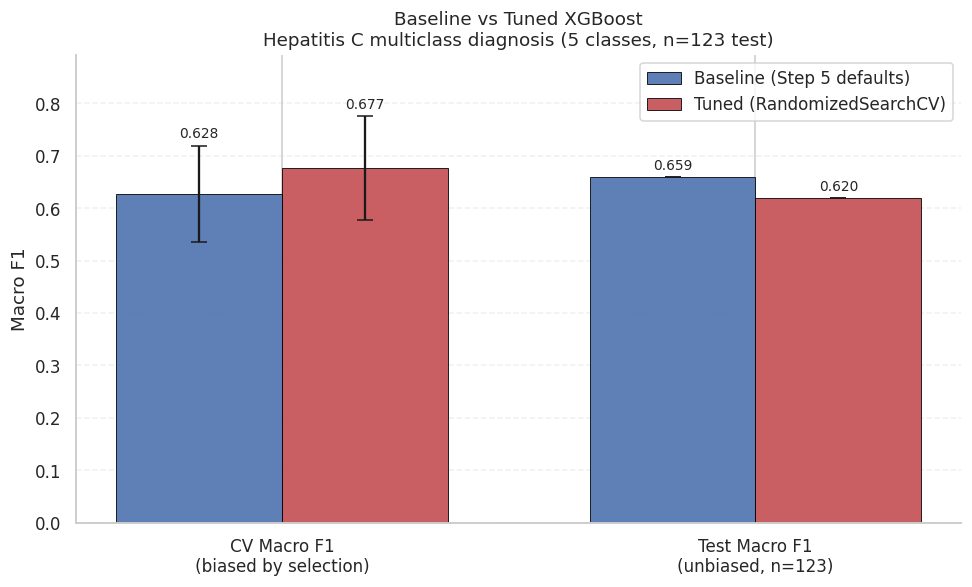

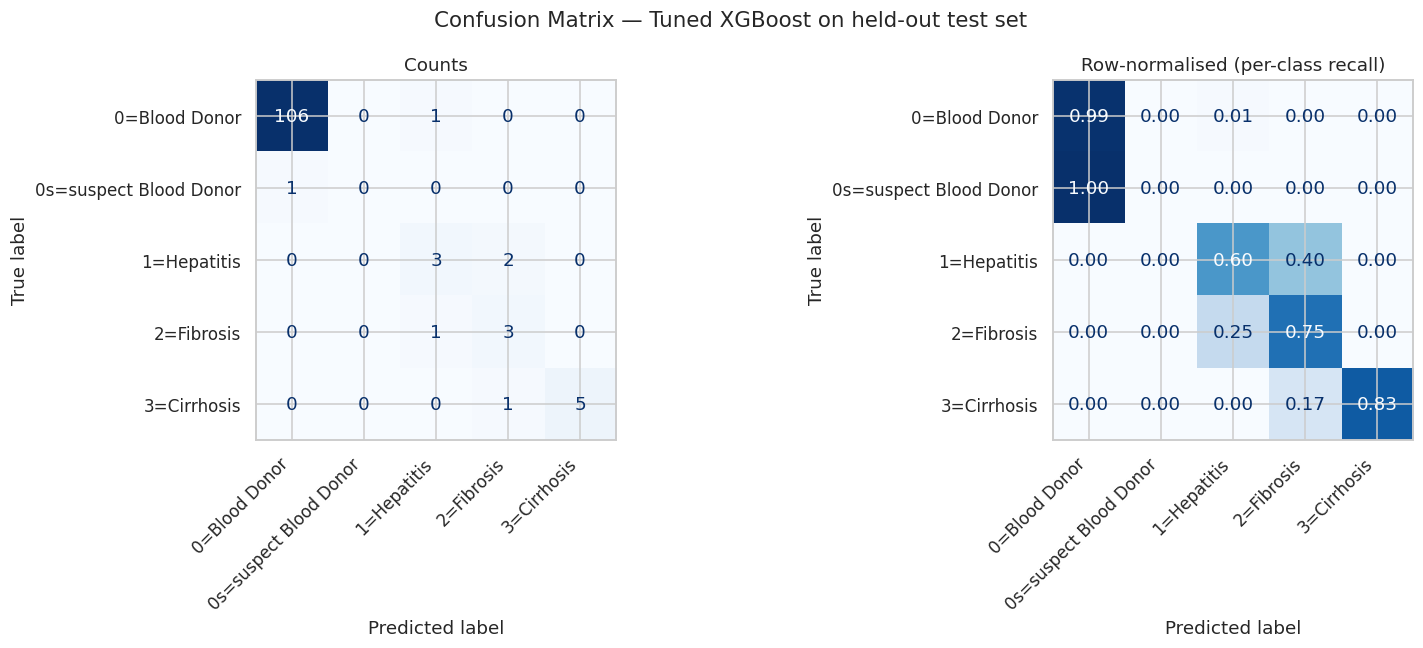


9. EXPORTS
best_tuned_model  : fitted Pipeline (prep -> sanitize -> clf)
best_params       : 7 parameters
tuning_results_df : (30, 13) (30 candidates ranked by rank_test_score)

Summary for the write-up:
  Search time            : 43.9 s
  Baseline CV Macro F1   : 0.6275 (+/- 0.0920)
  Tuned    CV Macro F1   : 0.6766 (+/- 0.0994)   [maximum over 30 candidates — optimistically biased]
  Baseline TEST Macro F1 : 0.6587   [unbiased]
  Tuned    TEST Macro F1 : 0.6199   [unbiased]

Step 7 must consume `best_tuned_model` as an already-fitted Pipeline and
must not refit it on data that includes X_test. Any further optimisation —
decision thresholds, cost-sensitive rules, probability calibration — has to
be cross-validated on X_train. X_test has now been spent.


In [32]:
# =============================================================================
# Step 6. Hyperparameter Tuning
#
# Consumes from Step 5:
#     best_model_name, best_model, results_df
#     X_train, X_test, y_train, y_test
#     build_preprocessing_pipeline(scale=True/False)
#     sanitizer                (feature-name shim)
#     BalancedXGBClassifier    (XGBClassifier with per-fold balanced weights)
#
# Tunes exactly one model — the baseline winner — over a freshly constructed
# Pipeline. Every transformation that learns from the data stays inside that
# Pipeline, so it is refitted on the training portion of each CV fold and never
# sees the held-out data.
#
# Exports: best_tuned_model, best_params, tuning_results_df
# =============================================================================

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110


def section(title):
    """Section header, identical in form to Steps 4 and 5."""
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# =============================================================================
# 1. PRECONDITIONS
# =============================================================================
section("1. Preconditions")

# Requirement 2 names two objects defined in Step 5 that are not in this step's
# nominal export list. Failing loudly here beats a NameError forty lines down,
# and beats the far worse alternative of silently substituting a stock
# XGBClassifier (see Section 3 for why that would be a modelling error, not a
# cosmetic one).
for _required in ("sanitizer", "BalancedXGBClassifier"):
    if _required not in dir():
        raise NameError(
            f"'{_required}' was defined in Step 5 and is required here. "
            f"Re-run the Step 5 cell before this one."
        )

# Requirement 1: tune only the winner. Every search consumes statistical
# evidence, and with 492 training rows there is very little to spend. Step 5
# spent its evidence deciding the ARCHITECTURE question (linear vs bagged vs
# boosted). This step spends its evidence on the CONFIGURATION question for the
# single architecture that survived. Tuning all five and then picking the best
# tuned model would take a maximum over ~5x more noisy estimates, inflating the
# optimism of the reported CV score without improving the model.
if best_model_name != "XGBoost":
    raise RuntimeError(
        f"This section implements tuning for XGBoost only, but Step 5 selected "
        f"'{best_model_name}'. The search space below is specific to "
        f"gradient-boosted trees. Define an appropriate space for "
        f"'{best_model_name}' before proceeding."
    )

# `label_encoder` is not among this step's declared inputs, so the class count is
# derived from the labels themselves rather than assumed. Names are recovered
# from the encoder if it happens to be in scope, otherwise the integer codes are
# used — the metrics are identical either way.
ALL_LABELS = np.unique(np.concatenate([y_train, y_test]))
N_CLASSES = len(ALL_LABELS)
try:
    CLASS_NAMES = list(label_encoder.classes_)
except NameError:
    CLASS_NAMES = [str(c) for c in ALL_LABELS]

print(f"Baseline winner from Step 5 : {best_model_name}")
print(f"Classes                     : {N_CLASSES} -> {CLASS_NAMES}")
print(f"Train / test                : {X_train.shape[0]} / {X_test.shape[0]} rows")
print("Preconditions satisfied.")


# =============================================================================
# 2. EXPERIMENTAL SETUP
# =============================================================================
section("2. Experimental setup")

RANDOM_STATE = 42
N_ITER = 30

# WHY THE SAME CV OBJECT AS STEP 5.
# The tuned model's CV score is comparable to the baseline's only if both were
# measured over identical fold boundaries. Changing n_splits here would leave us
# unable to tell whether a gain came from better hyperparameters or from an
# easier fold structure.
#
# WHY k=3. The rarest class contributes ~6 rows to X_train. StratifiedKFold puts
# at least one member of every class in every fold; k=3 leaves ~2. At k=5 it
# leaves ~1, and since Macro F1 weights all classes equally, one-fifth of the
# optimisation target would become a single Bernoulli trial. We would be tuning
# against noise. k=3 is not comfortable — it is the least uncomfortable option.
CV = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# WHY MACRO F1 REMAINS THE METRIC.
# 86.7% of rows are healthy donors. A model predicting that class unconditionally
# earns ~0.87 accuracy while detecting zero cases of liver disease. Macro F1
# averages per-class F1 with equal weight, so the 21 fibrosis cases count as much
# as the 533 donors, and it penalises both missed diagnoses and false alarms
# (unlike balanced accuracy, which is mean recall and ignores false-alarm cost).
PRIMARY_METRIC = "f1_macro"

print(f"Random state     : {RANDOM_STATE}")
print(f"Cross-validation : {CV}")
print(f"Primary metric   : {PRIMARY_METRIC}")
print(f"Search budget    : {N_ITER} candidates x {CV.get_n_splits()} folds "
      f"= {N_ITER * CV.get_n_splits()} pipeline fits")


# =============================================================================
# 3. FRESH TUNING PIPELINE
# =============================================================================
section("3. Tuning pipeline")

# WHY A FRESH ESTIMATOR AND NOT `best_model`.
# `best_model` is already fitted on X_train: its trees, imputation medians, and
# one-hot vocabulary all encode that fit. Handing it to RandomizedSearchCV would
# work — sklearn clones internally — but relying on that is fragile, and the
# instruction is explicit. Constructing from scratch also documents which
# arguments are FIXED versus SEARCHED, which a clone would hide.
#
# WHY BalancedXGBClassifier AND NOT XGBClassifier.
# XGBoost exposes no `class_weight` for multiclass problems; it accepts only
# per-row `sample_weight` at fit time. Step 5 subclassed it so `fit()` derives
# balanced weights from whatever `y` it receives — which, under cross-validation,
# is the training fold alone. Substituting a stock XGBClassifier here would
# silently discard the class balancing and tune a fundamentally different model
# from the one Step 5 benchmarked, making the comparison in Section 7 invalid.
#
# WHY `num_class` IS NOT PASSED.
# The sklearn API infers it from `classes_` at fit time. Passing it explicitly is
# redundant and becomes an active liability if any downstream utility (e.g.
# learning_curve) ever fits on a subsample missing a class: the declared count
# and the observed count then disagree and XGBoost raises.
#
# WHY THE ESTIMATOR GETS n_jobs=1.
# The search below uses n_jobs=-1, so sklearn already forks one worker per core.
# Leaving XGBoost's own n_jobs at -1 would have each worker spawn a full thread
# pool, oversubscribing the CPU. The usual result is a search that runs slower
# than single-threaded.
xgb_estimator = BalancedXGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# WHY scale=False.
# Gradient-boosted trees split on rank order, which is invariant to any monotone
# rescaling. A StandardScaler would change nothing about the fitted trees while
# adding a fitted transformer to each of the 90 fits. Pure overhead. (Logistic
# Regression would need scale=True: its L2 penalty is applied uniformly across
# coefficients, so unscaled features would be penalised in proportion to their
# units — CREA in the hundreds crushed against CHE in single digits.)
#
# WHY THE PREPROCESSING MUST STAY INSIDE THE PIPELINE.
# RandomizedSearchCV calls .fit() on this object once per candidate per fold. If
# it were handed a pre-transformed matrix, the imputation medians and the one-hot
# vocabulary would already have been computed on all of X_train — including each
# fold's validation rows. Every one of the 90 fits would then be scored on data
# whose preprocessing statistics it had seen. The corruption is dangerous
# precisely because it is small: the CV score creeps up, the search converges on
# hyperparameters tuned to a leak, and nothing crashes.
tuning_pipeline = Pipeline([
    ("prep", build_preprocessing_pipeline(scale=False)),
    ("sanitize", sanitizer),
    ("clf", xgb_estimator),
])

print("Freshly constructed, unfitted pipeline:")
for name, step in tuning_pipeline.named_steps.items():
    print(f"  {name:<10} -> {type(step).__name__}")

print("\n  prep     : Step 4 preprocessing. Feature engineering (stateless),")
print("             median imputation (FITTED), one-hot encoding (FITTED).")
print("  sanitize : strips '<', '[', ']' from feature names. XGBoost raises")
print("             ValueError on 'AgeGroup_<35'. Stateless.")
print("  clf      : BalancedXGBClassifier — recomputes balanced sample weights")
print("             from each training fold's labels.")

print("\nX_test is not referenced in Sections 3-6. It enters once, in Section 7.")


# =============================================================================
# 4. SEARCH SPACE
# =============================================================================
section("4. Search space")

# Keys are namespaced `clf__` so they address the estimator inside the pipeline,
# never the preprocessing.
#
# WHY THESE RANGES ARE APPROPRIATE FOR ~600 ROWS.
# Every ceiling below is set by the sample size, not by convention:
#
#   n_estimators [100..500]   Boosting exhausts the residual quickly on 492 rows.
#                             Beyond ~500 rounds the added trees fit noise, and
#                             the shrinkage from a low learning_rate is the only
#                             thing keeping them harmless. Lower bias, higher
#                             variance as this rises.
#
#   max_depth [3..6]          The interaction order the trees can express, and the
#                             most direct variance control. Depth 3 combines three
#                             features per path; depth 6 can carve out a specific
#                             patient profile. Capped at 6 deliberately — a depth-8
#                             tree on 492 rows is memorising individuals.
#
#   learning_rate [0.01..0.1] Shrinks each tree's contribution. Low rate -> each
#                             round commits less -> better generalisation but more
#                             rounds needed. learning_rate and n_estimators are
#                             near-inverses; sampling both lets the search find any
#                             point on that trade-off rather than assuming one.
#
#   subsample [0.7..1.0]      Row fraction per tree. Decorrelates trees -> lower
#                             variance, slightly higher bias. The floor is 0.7
#                             because below that the 21 fibrosis and 6 suspect-donor
#                             rows start vanishing from individual trees entirely.
#
#   colsample_bytree [0.7..1.0] Same mechanism on the feature axis. After one-hot
#                             encoding there are ~21 columns; 0.7 leaves ~15,
#                             enough to keep the informative liver markers
#                             reachable in most trees.
#
#   min_child_weight [1,3,5]  Minimum summed instance weight per leaf. Higher ->
#                             refuses to isolate small groups -> higher bias.
#
#                             *** Subtlety specific to this dataset. *** Because
#                             BalancedXGBClassifier applies balanced weights, a
#                             single fibrosis patient carries weight ~4.7 and a
#                             suspect-donor row ~16. min_child_weight=5 is therefore
#                             satisfied by ONE rare-class patient but demands ~14
#                             healthy donors. The parameter is far less restrictive
#                             for the minority classes than the same value would be
#                             on balanced data — desirable here, but it means these
#                             numbers are not comparable to values quoted in
#                             tutorials on balanced problems.
#
#   gamma [0..0.5]            Minimum loss reduction required to make a split: a
#                             direct pruning threshold. gamma=0 splits whenever the
#                             loss falls at all; gamma=0.5 demands the split earn
#                             its complexity. Purely bias-increasing,
#                             variance-decreasing.
#
# NOT searched, deliberately: the balanced sample weighting. It is not a
# hyperparameter but a statement of clinical cost — a missed cirrhosis diagnosis
# is worse than a false alarm on a healthy donor. Letting the search switch it off
# would spend budget rediscovering the trivial majority-class solution that Macro
# F1 exists to reject.
param_distributions = {
    "clf__n_estimators": [100, 200, 300, 400, 500],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
}

grid_size = int(np.prod([len(v) for v in param_distributions.values()]))

print("Parameter distributions:")
for k, v in param_distributions.items():
    print(f"  {k:<26} {v}")

print(f"\nExhaustive grid : {grid_size:,} combinations "
      f"({grid_size * CV.get_n_splits():,} fits)")
print(f"Sampled         : {N_ITER} candidates "
      f"({N_ITER / grid_size:.2%} of the space, "
      f"{N_ITER * CV.get_n_splits()} fits)")

# WHY RandomizedSearchCV RATHER THAN GridSearchCV.
#
# 1. Cost. The grid holds 15,360 combinations; exhaustive search means 46,080
#    pipeline fits against our 90. A 512x increase.
#
# 2. Better coverage per unit of budget (Bergstra & Bengio, 2012). Under a fixed
#    budget B, a grid tests only B^(1/7) distinct values of each of our seven
#    parameters, while random search tests up to B distinct values of each. Only
#    two or three of these seven materially affect Macro F1 — and we do not know
#    which in advance — so a grid wastes most evaluations re-testing identical
#    values of parameters that do not matter.
#
# 3. The decisive argument, specific to this dataset: 615 rows cannot RESOLVE a
#    fine grid. Step 5 measured fold-to-fold standard deviations of ~0.03-0.06
#    Macro F1. The score difference between learning_rate 0.03 and 0.05, or
#    max_depth 4 and 5, sits well below that. An exhaustive grid would rank all
#    15,360 candidates and name a winner, but the ordering among the leaders would
#    be decided almost entirely by which configuration happened to suit these
#    three fold boundaries. Spending 512x the compute to sharpen a ranking the
#    data cannot support is not rigour; it is expensive noise.


# =============================================================================
# 5. RUN THE SEARCH
# =============================================================================
section("5. Running the search")

# `refit=True`: after every candidate has been CV-scored, refit the single best
# configuration on the whole of X_train. That refit runs the full pipeline, so
# the preprocessing is fitted on X_train and nothing else.
#
# `error_score=np.nan`: a candidate that fails to fit scores NaN and is excluded
# from the ranking rather than aborting the search.
search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring=PRIMARY_METRIC,
    cv=CV,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,   # enables the overfit diagnostic below
    error_score=np.nan,
    verbose=1,
)

print("Fitting on X_train only. X_test is not in scope.\n")

_t0 = time.perf_counter()
with warnings.catch_warnings():
    # In folds where a rare class is never predicted, sklearn warns about
    # undefined precision. The documented zero-division default (0.0) is the
    # behaviour we want; the warning is noise at 90 repetitions.
    warnings.simplefilter("ignore")
    search.fit(X_train, y_train)
search_time = time.perf_counter() - _t0

best_params = search.best_params_
best_index = search.best_index_
n_evaluated = len(search.cv_results_["params"])
n_failed = int(np.isnan(search.cv_results_["mean_test_score"]).sum())

mean_cv = search.cv_results_["mean_test_score"][best_index]
std_cv = search.cv_results_["std_test_score"][best_index]
mean_train = search.cv_results_["mean_train_score"][best_index]

print("\n" + "-" * 78)
print("SEARCH RESULTS")
print("-" * 78)
print(f"Search time            : {search_time:.1f} s "
      f"({search_time / (n_evaluated * CV.get_n_splits()):.2f} s per fit)")
print(f"Candidates evaluated   : {n_evaluated}")
if n_failed:
    print(f"Failed (scored NaN)    : {n_failed} — excluded from the ranking")

print(f"\nBest CV Macro F1       : {search.best_score_:.4f}")
print(f"Mean CV Macro F1       : {mean_cv:.4f}")
print(f"Std across folds       : {std_cv:.4f}")

print("\nBest parameters:")
for k, v in sorted(best_params.items()):
    print(f"  {k:<26} {v}")

# --- Per-fold detail and the overfit gap -------------------------------------
fold_scores = [
    search.cv_results_[f"split{i}_test_score"][best_index]
    for i in range(CV.get_n_splits())
]
overfit_gap = mean_train - mean_cv

print(f"\nWinner's per-fold Macro F1 : "
      f"{', '.join(f'{s:.4f}' for s in fold_scores)}")
print(f"Mean TRAIN-fold Macro F1   : {mean_train:.4f}")
print(f"Train-validation gap       : {overfit_gap:.4f}")
if overfit_gap > 0.20:
    print("  -> The winner fits the training folds far better than the validation")
    print("     folds. Expect the test score in Section 7 to land near the CV")
    print("     score, not near the training score.")


# =============================================================================
# 5b. TUNING RESULTS TABLE
# =============================================================================
section("5b. Candidate ranking")

tuning_results_df = pd.DataFrame(search.cv_results_)

param_cols = [c for c in tuning_results_df.columns if c.startswith("param_")]
keep_cols = (
    ["rank_test_score", "mean_test_score", "std_test_score",
     "mean_train_score", "mean_fit_time"]
    + param_cols
)
tuning_results_df = (
    tuning_results_df[keep_cols]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

# An explicit overfit column makes it visible when a high-ranking candidate is
# scoring well by memorising rather than generalising.
tuning_results_df.insert(
    3, "overfit_gap",
    tuning_results_df["mean_train_score"] - tuning_results_df["mean_test_score"],
)

print("Top 10 candidates, ranked by CV Macro F1:\n")
print(tuning_results_df.head(10).round(4).to_string(index=False))

# --- Is the top of the ranking meaningful? -----------------------------------
# If the spread across the leading candidates is smaller than the fold-to-fold
# standard deviation, the search has located a plateau rather than a peak, and
# `best_params` is simply wherever the sampler happened to land.
top10 = tuning_results_df.head(10)
spread = top10["mean_test_score"].max() - top10["mean_test_score"].min()
typical_std = top10["std_test_score"].mean()

print(f"\nSpread across top-10 : {spread:.4f}")
print(f"Typical fold std     : {typical_std:.4f}")
if spread < typical_std:
    print("  -> The response surface is FLAT relative to noise. Any of these ten")
    print("     configurations would serve. Do not over-interpret `best_params`.")
else:
    print("  -> The leaders are separated by more than the fold noise: weak")
    print("     evidence that the ranking reflects something real.")


# =============================================================================
# 6. TUNED MODEL — HELD-OUT TEST EVALUATION
# =============================================================================
section("6. Test evaluation")

# `refit=True` already refitted the winning configuration on all of X_train,
# running the full pipeline. Model selection is complete; what follows is a
# single confirmation, not a search.
best_tuned_model = search.best_estimator_

# The one and only time X_test is used in this section.
y_pred_tuned = best_tuned_model.predict(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_tuned),
    "Macro F1": f1_score(y_test, y_pred_tuned, average="macro", zero_division=0),
}

print("Tuned XGBoost — held-out test metrics")
print("-" * 78)
for name, value in tuned_metrics.items():
    print(f"  {name:<20} {value:.4f}")

print("\nClassification report:\n")
print(classification_report(
    y_test, y_pred_tuned,
    labels=ALL_LABELS,
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=3,
))

print("Confusion matrix (rows = true, columns = predicted):")
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=ALL_LABELS)
print(pd.DataFrame(cm_tuned, index=CLASS_NAMES, columns=CLASS_NAMES))


# =============================================================================
# 7. BASELINE vs TUNED
# =============================================================================
section("7. Baseline vs tuned")

# The baseline's CV Macro F1 comes from Step 5's results_df, which was computed
# with the same CV object and the same metric — the only reason the two numbers
# can be placed side by side. Its test metrics are computed here from the fitted
# `best_model`, so both rows of the table are produced by identical procedures.
baseline_row = results_df.loc[results_df["Model"] == best_model_name].iloc[0]
baseline_cv_f1 = baseline_row["CV F1 Macro"]
baseline_cv_std = baseline_row["CV F1 Std"]

y_pred_base = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Baseline": {
        "CV Macro F1": baseline_cv_f1,
        "Test Macro F1": f1_score(y_test, y_pred_base,
                                  average="macro", zero_division=0),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_base),
        "Test Accuracy": accuracy_score(y_test, y_pred_base),
    },
    "Tuned": {
        "CV Macro F1": search.best_score_,
        "Test Macro F1": tuned_metrics["Macro F1"],
        "Test Balanced Accuracy": tuned_metrics["Balanced Accuracy"],
        "Test Accuracy": tuned_metrics["Accuracy"],
    },
})
comparison_df["Abs. change"] = comparison_df["Tuned"] - comparison_df["Baseline"]
comparison_df["Rel. change %"] = (
    comparison_df["Abs. change"] / comparison_df["Baseline"] * 100
)

print(comparison_df.round(4).to_string())

# --- Did tuning genuinely improve the model? ---------------------------------
cv_gain = search.best_score_ - baseline_cv_f1
test_gain = comparison_df.loc["Test Macro F1", "Abs. change"]
pooled_std = np.sqrt((baseline_cv_std ** 2 + std_cv ** 2) / 2)

print(f"\nCV Macro F1 gain   : {cv_gain:+.4f}   (pooled fold std {pooled_std:.4f})")
print(f"Test Macro F1 gain : {test_gain:+.4f}")

# THE WINNER'S CURSE — the one caveat that must not be omitted from the write-up.
# `search.best_score_` is the MAXIMUM over 30 candidates scored on the SAME three
# folds. The maximum of many noisy estimates is upwardly biased: part of that
# score is the winning candidate genuinely being better, part is that candidate
# happening to suit these particular fold boundaries. The baseline's CV score
# suffers no such bias — it is a single estimate, not a maximum. The CV row above
# therefore systematically FAVOURS the tuned model. The test row does not: neither
# model was ever tuned against X_test.
print("\nInterpretation:")
if cv_gain <= 0:
    print("  The CV score did not improve. The Step 5 defaults were already at or")
    print("  beyond the plateau. This is a legitimate result — report it rather")
    print("  than widening the search until something wins.")
elif cv_gain < pooled_std:
    print("  The CV gain is smaller than one pooled fold-to-fold standard")
    print("  deviation. It is not distinguishable from noise.")
else:
    print("  The CV gain exceeds one pooled standard deviation: weak evidence of a")
    print("  real improvement. With three folds this is far from a significance")
    print("  test.")

print(f"\n  Note that the tuned CV score ({search.best_score_:.4f}) is a maximum over")
print(f"  {n_evaluated} candidates on the same folds, and is therefore optimistically")
print(f"  biased. The baseline's is a single estimate and is not. The honest")
print(f"  comparison is the test row: {comparison_df.loc['Test Macro F1', 'Baseline']:.4f} "
      f"-> {comparison_df.loc['Test Macro F1', 'Tuned']:.4f}.")

if np.sign(test_gain) != np.sign(cv_gain) and abs(test_gain) > 0.01:
    print("\n  *** The test score moved OPPOSITE to the CV score. This is the")
    print("  winner's curse made visible: the search improved the fit to the fold")
    print("  boundaries, not to the problem. Trust the test set — it is the only")
    print("  estimate the search never optimised against.")

# Resolution of the test set itself: with 4 fibrosis rows in X_test, one flipped
# prediction moves that class's recall by 0.25 and Macro F1 by ~0.05.
resolution = 0.25 / N_CLASSES
n_minority = int((y_test != np.bincount(y_test).argmax()).sum())
print(f"\n  Test-set resolution: {len(y_test)} rows, {n_minority} non-majority. One")
print(f"  flipped prediction in a 4-row class moves Macro F1 by ~{resolution:.3f}.")
print(f"  Differences below that are below the instrument's resolution.")


# =============================================================================
# 8. VISUALISATIONS
# =============================================================================
section("8. Visualisations")

# --- Figure 1: baseline vs tuned Macro F1 ------------------------------------
# CV and test are plotted side by side deliberately. The CV pair is where the
# winner's curse lives; the test pair is the honest comparison. Plotting them
# together makes any divergence immediately visible. The CV bars carry
# fold-to-fold error bars; the test bars carry none — not because they are
# precise, but because a single split has no spread to report.
fig, ax = plt.subplots(figsize=(9, 5.5))

groups = ["CV Macro F1\n(biased by selection)",
          f"Test Macro F1\n(unbiased, n={len(y_test)})"]
baseline_vals = [baseline_cv_f1, comparison_df.loc["Test Macro F1", "Baseline"]]
tuned_vals = [search.best_score_, comparison_df.loc["Test Macro F1", "Tuned"]]

x = np.arange(len(groups))
width = 0.35

b1 = ax.bar(x - width / 2, baseline_vals, width,
            yerr=[baseline_cv_std, 0.0], capsize=5,
            label="Baseline (Step 5 defaults)", color="#4c72b0",
            edgecolor="black", linewidth=0.6, alpha=0.9)
b2 = ax.bar(x + width / 2, tuned_vals, width,
            yerr=[std_cv, 0.0], capsize=5,
            label="Tuned (RandomizedSearchCV)", color="#c44e52",
            edgecolor="black", linewidth=0.6, alpha=0.9)

ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("Macro F1")
ax.set_title(f"Baseline vs Tuned {best_model_name}\n"
             f"Hepatitis C multiclass diagnosis (5 classes, n={len(y_test)} test)")
ax.set_ylim(0, max(max(baseline_vals), max(tuned_vals)) * 1.32)
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# --- Figure 2: confusion matrix of the tuned model ---------------------------
# Counts and row-normalised recall, side by side. On an 87/13 class split the
# raw-count matrix is one dark square and four faint ones; row normalisation
# exposes the per-class recall, which is the quantity a clinician cares about.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=CLASS_NAMES,
).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Counts")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test, y_pred_tuned, labels=ALL_LABELS, normalize="true"
    ),
    display_labels=CLASS_NAMES,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Row-normalised (per-class recall)")

for ax_ in axes:
    ax_.tick_params(axis="x", rotation=45)
    for lbl in ax_.get_xticklabels():
        lbl.set_ha("right")
    ax_.set_xlabel("Predicted label")
    ax_.set_ylabel("True label")

fig.suptitle(f"Confusion Matrix — Tuned {best_model_name} on held-out test set",
             fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# 9. EXPORTS
# =============================================================================
section("9. Exports")

print(f"best_tuned_model  : fitted Pipeline "
      f"({' -> '.join(best_tuned_model.named_steps)})")
print(f"best_params       : {len(best_params)} parameters")
print(f"tuning_results_df : {tuning_results_df.shape} "
      f"({n_evaluated} candidates ranked by rank_test_score)")

print("\nSummary for the write-up:")
print(f"  Search time            : {search_time:.1f} s")
print(f"  Baseline CV Macro F1   : {baseline_cv_f1:.4f} (+/- {baseline_cv_std:.4f})")
print(f"  Tuned    CV Macro F1   : {search.best_score_:.4f} (+/- {std_cv:.4f})"
      f"   [maximum over {n_evaluated} candidates — optimistically biased]")
print(f"  Baseline TEST Macro F1 : "
      f"{comparison_df.loc['Test Macro F1', 'Baseline']:.4f}   [unbiased]")
print(f"  Tuned    TEST Macro F1 : "
      f"{comparison_df.loc['Test Macro F1', 'Tuned']:.4f}   [unbiased]")

print("\nStep 7 must consume `best_tuned_model` as an already-fitted Pipeline and")
print("must not refit it on data that includes X_test. Any further optimisation —")
print("decision thresholds, cost-sensitive rules, probability calibration — has to")
print("be cross-validated on X_train. X_test has now been spent.")


1. PRECONDITIONS
Baseline winner from Step 5 : XGBoost
Classes                     : 5 -> ['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis']
Train / test                : 492 / 123 rows
Preconditions satisfied.

2. EXPERIMENTAL SETUP
Random state     : 42
Cross-validation : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
Primary metric   : f1_macro
Search budget    : 30 candidates x 3 folds = 90 pipeline fits

3. TUNING PIPELINE
Freshly constructed, unfitted pipeline:
  prep       -> Pipeline
  sanitize   -> FunctionTransformer
  clf        -> BalancedXGBClassifier

  prep     : Step 4 preprocessing. Feature engineering (stateless),
             median imputation (FITTED), one-hot encoding (FITTED).
  sanitize : strips '<', '[', ']' from feature names. XGBoost raises
             ValueError on 'AgeGroup_<35'. Stateless.
  clf      : BalancedXGBClassifier — recomputes balanced sample weights
             from each training fold's labels.


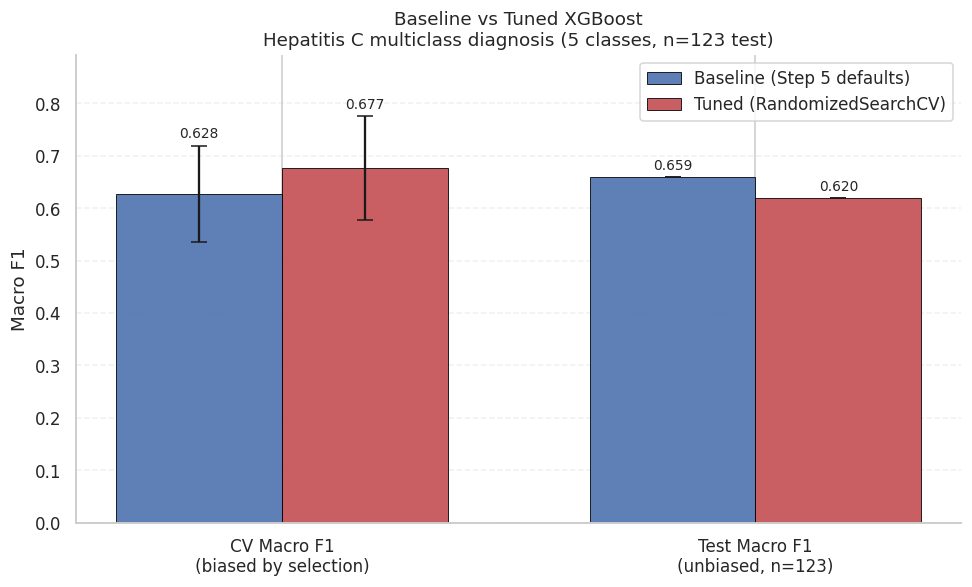

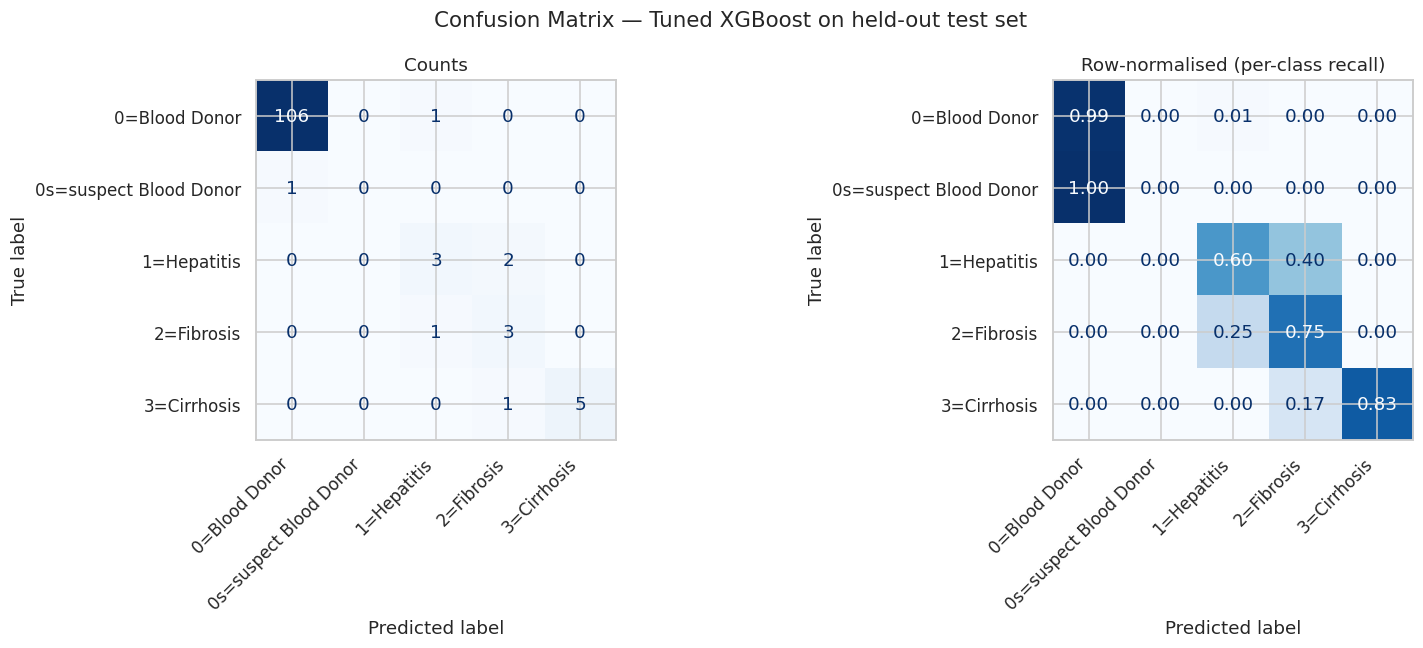


9. EXPORTS
best_tuned_model  : fitted Pipeline (prep -> sanitize -> clf)
best_params       : 7 parameters
tuning_results_df : (30, 13) (30 candidates ranked by rank_test_score)

Summary for the write-up:
  Search time            : 25.4 s
  Baseline CV Macro F1   : 0.6275 (+/- 0.0920)
  Tuned    CV Macro F1   : 0.6766 (+/- 0.0994)   [maximum over 30 candidates — optimistically biased]
  Baseline TEST Macro F1 : 0.6587   [unbiased]
  Tuned    TEST Macro F1 : 0.6199   [unbiased]

Step 7 must consume `best_tuned_model` as an already-fitted Pipeline and
must not refit it on data that includes X_test. Any further optimisation —
decision thresholds, cost-sensitive rules, probability calibration — has to
be cross-validated on X_train. X_test has now been spent.


In [33]:
# =============================================================================
# Step 6. Hyperparameter Tuning
#
# Consumes from Step 5:
#     best_model_name, best_model, results_df
#     X_train, X_test, y_train, y_test
#     build_preprocessing_pipeline(scale=True/False)
#     sanitizer                (feature-name shim)
#     BalancedXGBClassifier    (XGBClassifier with per-fold balanced weights)
#
# Tunes exactly one model — the baseline winner — over a freshly constructed
# Pipeline. Every transformation that learns from the data stays inside that
# Pipeline, so it is refitted on the training portion of each CV fold and never
# sees the held-out data.
#
# Exports: best_tuned_model, best_params, tuning_results_df
# =============================================================================

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110


def section(title):
    """Section header, identical in form to Steps 4 and 5."""
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# =============================================================================
# 1. PRECONDITIONS
# =============================================================================
section("1. Preconditions")

# Requirement 2 names two objects defined in Step 5 that are not in this step's
# nominal export list. Failing loudly here beats a NameError forty lines down,
# and beats the far worse alternative of silently substituting a stock
# XGBClassifier (see Section 3 for why that would be a modelling error, not a
# cosmetic one).
for _required in ("sanitizer", "BalancedXGBClassifier"):
    if _required not in dir():
        raise NameError(
            f"'{_required}' was defined in Step 5 and is required here. "
            f"Re-run the Step 5 cell before this one."
        )

# Requirement 1: tune only the winner. Every search consumes statistical
# evidence, and with 492 training rows there is very little to spend. Step 5
# spent its evidence deciding the ARCHITECTURE question (linear vs bagged vs
# boosted). This step spends its evidence on the CONFIGURATION question for the
# single architecture that survived. Tuning all five and then picking the best
# tuned model would take a maximum over ~5x more noisy estimates, inflating the
# optimism of the reported CV score without improving the model.
if best_model_name != "XGBoost":
    raise RuntimeError(
        f"This section implements tuning for XGBoost only, but Step 5 selected "
        f"'{best_model_name}'. The search space below is specific to "
        f"gradient-boosted trees. Define an appropriate space for "
        f"'{best_model_name}' before proceeding."
    )

# `label_encoder` is not among this step's declared inputs, so the class count is
# derived from the labels themselves rather than assumed. Names are recovered
# from the encoder if it happens to be in scope, otherwise the integer codes are
# used — the metrics are identical either way.
ALL_LABELS = np.unique(np.concatenate([y_train, y_test]))
N_CLASSES = len(ALL_LABELS)
try:
    CLASS_NAMES = list(label_encoder.classes_)
except NameError:
    CLASS_NAMES = [str(c) for c in ALL_LABELS]

print(f"Baseline winner from Step 5 : {best_model_name}")
print(f"Classes                     : {N_CLASSES} -> {CLASS_NAMES}")
print(f"Train / test                : {X_train.shape[0]} / {X_test.shape[0]} rows")
print("Preconditions satisfied.")


# =============================================================================
# 2. EXPERIMENTAL SETUP
# =============================================================================
section("2. Experimental setup")

RANDOM_STATE = 42
N_ITER = 30

# WHY THE SAME CV OBJECT AS STEP 5.
# The tuned model's CV score is comparable to the baseline's only if both were
# measured over identical fold boundaries. Changing n_splits here would leave us
# unable to tell whether a gain came from better hyperparameters or from an
# easier fold structure.
#
# WHY k=3. The rarest class contributes ~6 rows to X_train. StratifiedKFold puts
# at least one member of every class in every fold; k=3 leaves ~2. At k=5 it
# leaves ~1, and since Macro F1 weights all classes equally, one-fifth of the
# optimisation target would become a single Bernoulli trial. We would be tuning
# against noise. k=3 is not comfortable — it is the least uncomfortable option.
CV = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# WHY MACRO F1 REMAINS THE METRIC.
# 86.7% of rows are healthy donors. A model predicting that class unconditionally
# earns ~0.87 accuracy while detecting zero cases of liver disease. Macro F1
# averages per-class F1 with equal weight, so the 21 fibrosis cases count as much
# as the 533 donors, and it penalises both missed diagnoses and false alarms
# (unlike balanced accuracy, which is mean recall and ignores false-alarm cost).
PRIMARY_METRIC = "f1_macro"

print(f"Random state     : {RANDOM_STATE}")
print(f"Cross-validation : {CV}")
print(f"Primary metric   : {PRIMARY_METRIC}")
print(f"Search budget    : {N_ITER} candidates x {CV.get_n_splits()} folds "
      f"= {N_ITER * CV.get_n_splits()} pipeline fits")


# =============================================================================
# 3. FRESH TUNING PIPELINE
# =============================================================================
section("3. Tuning pipeline")

# WHY A FRESH ESTIMATOR AND NOT `best_model`.
# `best_model` is already fitted on X_train: its trees, imputation medians, and
# one-hot vocabulary all encode that fit. Handing it to RandomizedSearchCV would
# work — sklearn clones internally — but relying on that is fragile, and the
# instruction is explicit. Constructing from scratch also documents which
# arguments are FIXED versus SEARCHED, which a clone would hide.
#
# WHY BalancedXGBClassifier AND NOT XGBClassifier.
# XGBoost exposes no `class_weight` for multiclass problems; it accepts only
# per-row `sample_weight` at fit time. Step 5 subclassed it so `fit()` derives
# balanced weights from whatever `y` it receives — which, under cross-validation,
# is the training fold alone. Substituting a stock XGBClassifier here would
# silently discard the class balancing and tune a fundamentally different model
# from the one Step 5 benchmarked, making the comparison in Section 7 invalid.
#
# WHY `num_class` IS NOT PASSED.
# The sklearn API infers it from `classes_` at fit time. Passing it explicitly is
# redundant and becomes an active liability if any downstream utility (e.g.
# learning_curve) ever fits on a subsample missing a class: the declared count
# and the observed count then disagree and XGBoost raises.
#
# WHY THE ESTIMATOR GETS n_jobs=1.
# The search below uses n_jobs=-1, so sklearn already forks one worker per core.
# Leaving XGBoost's own n_jobs at -1 would have each worker spawn a full thread
# pool, oversubscribing the CPU. The usual result is a search that runs slower
# than single-threaded.
xgb_estimator = BalancedXGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# WHY scale=False.
# Gradient-boosted trees split on rank order, which is invariant to any monotone
# rescaling. A StandardScaler would change nothing about the fitted trees while
# adding a fitted transformer to each of the 90 fits. Pure overhead. (Logistic
# Regression would need scale=True: its L2 penalty is applied uniformly across
# coefficients, so unscaled features would be penalised in proportion to their
# units — CREA in the hundreds crushed against CHE in single digits.)
#
# WHY THE PREPROCESSING MUST STAY INSIDE THE PIPELINE.
# RandomizedSearchCV calls .fit() on this object once per candidate per fold. If
# it were handed a pre-transformed matrix, the imputation medians and the one-hot
# vocabulary would already have been computed on all of X_train — including each
# fold's validation rows. Every one of the 90 fits would then be scored on data
# whose preprocessing statistics it had seen. The corruption is dangerous
# precisely because it is small: the CV score creeps up, the search converges on
# hyperparameters tuned to a leak, and nothing crashes.
tuning_pipeline = Pipeline([
    ("prep", build_preprocessing_pipeline(scale=False)),
    ("sanitize", sanitizer),
    ("clf", xgb_estimator),
])

print("Freshly constructed, unfitted pipeline:")
for name, step in tuning_pipeline.named_steps.items():
    print(f"  {name:<10} -> {type(step).__name__}")

print("\n  prep     : Step 4 preprocessing. Feature engineering (stateless),")
print("             median imputation (FITTED), one-hot encoding (FITTED).")
print("  sanitize : strips '<', '[', ']' from feature names. XGBoost raises")
print("             ValueError on 'AgeGroup_<35'. Stateless.")
print("  clf      : BalancedXGBClassifier — recomputes balanced sample weights")
print("             from each training fold's labels.")

print("\nX_test is not referenced in Sections 3-6. It enters once, in Section 7.")


# =============================================================================
# 4. SEARCH SPACE
# =============================================================================
section("4. Search space")

# Keys are namespaced `clf__` so they address the estimator inside the pipeline,
# never the preprocessing.
#
# WHY THESE RANGES ARE APPROPRIATE FOR ~600 ROWS.
# Every ceiling below is set by the sample size, not by convention:
#
#   n_estimators [100..500]   Boosting exhausts the residual quickly on 492 rows.
#                             Beyond ~500 rounds the added trees fit noise, and
#                             the shrinkage from a low learning_rate is the only
#                             thing keeping them harmless. Lower bias, higher
#                             variance as this rises.
#
#   max_depth [3..6]          The interaction order the trees can express, and the
#                             most direct variance control. Depth 3 combines three
#                             features per path; depth 6 can carve out a specific
#                             patient profile. Capped at 6 deliberately — a depth-8
#                             tree on 492 rows is memorising individuals.
#
#   learning_rate [0.01..0.1] Shrinks each tree's contribution. Low rate -> each
#                             round commits less -> better generalisation but more
#                             rounds needed. learning_rate and n_estimators are
#                             near-inverses; sampling both lets the search find any
#                             point on that trade-off rather than assuming one.
#
#   subsample [0.7..1.0]      Row fraction per tree. Decorrelates trees -> lower
#                             variance, slightly higher bias. The floor is 0.7
#                             because below that the 21 fibrosis and 6 suspect-donor
#                             rows start vanishing from individual trees entirely.
#
#   colsample_bytree [0.7..1.0] Same mechanism on the feature axis. After one-hot
#                             encoding there are ~21 columns; 0.7 leaves ~15,
#                             enough to keep the informative liver markers
#                             reachable in most trees.
#
#   min_child_weight [1,3,5]  Minimum summed instance weight per leaf. Higher ->
#                             refuses to isolate small groups -> higher bias.
#
#                             *** Subtlety specific to this dataset. *** Because
#                             BalancedXGBClassifier applies balanced weights, a
#                             single fibrosis patient carries weight ~4.7 and a
#                             suspect-donor row ~16. min_child_weight=5 is therefore
#                             satisfied by ONE rare-class patient but demands ~14
#                             healthy donors. The parameter is far less restrictive
#                             for the minority classes than the same value would be
#                             on balanced data — desirable here, but it means these
#                             numbers are not comparable to values quoted in
#                             tutorials on balanced problems.
#
#   gamma [0..0.5]            Minimum loss reduction required to make a split: a
#                             direct pruning threshold. gamma=0 splits whenever the
#                             loss falls at all; gamma=0.5 demands the split earn
#                             its complexity. Purely bias-increasing,
#                             variance-decreasing.
#
# NOT searched, deliberately: the balanced sample weighting. It is not a
# hyperparameter but a statement of clinical cost — a missed cirrhosis diagnosis
# is worse than a false alarm on a healthy donor. Letting the search switch it off
# would spend budget rediscovering the trivial majority-class solution that Macro
# F1 exists to reject.
param_distributions = {
    "clf__n_estimators": [100, 200, 300, 400, 500],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
}

grid_size = int(np.prod([len(v) for v in param_distributions.values()]))

print("Parameter distributions:")
for k, v in param_distributions.items():
    print(f"  {k:<26} {v}")

print(f"\nExhaustive grid : {grid_size:,} combinations "
      f"({grid_size * CV.get_n_splits():,} fits)")
print(f"Sampled         : {N_ITER} candidates "
      f"({N_ITER / grid_size:.2%} of the space, "
      f"{N_ITER * CV.get_n_splits()} fits)")

# WHY RandomizedSearchCV RATHER THAN GridSearchCV.
#
# 1. Cost. The grid holds 15,360 combinations; exhaustive search means 46,080
#    pipeline fits against our 90. A 512x increase.
#
# 2. Better coverage per unit of budget (Bergstra & Bengio, 2012). Under a fixed
#    budget B, a grid tests only B^(1/7) distinct values of each of our seven
#    parameters, while random search tests up to B distinct values of each. Only
#    two or three of these seven materially affect Macro F1 — and we do not know
#    which in advance — so a grid wastes most evaluations re-testing identical
#    values of parameters that do not matter.
#
# 3. The decisive argument, specific to this dataset: 615 rows cannot RESOLVE a
#    fine grid. Step 5 measured fold-to-fold standard deviations of ~0.03-0.06
#    Macro F1. The score difference between learning_rate 0.03 and 0.05, or
#    max_depth 4 and 5, sits well below that. An exhaustive grid would rank all
#    15,360 candidates and name a winner, but the ordering among the leaders would
#    be decided almost entirely by which configuration happened to suit these
#    three fold boundaries. Spending 512x the compute to sharpen a ranking the
#    data cannot support is not rigour; it is expensive noise.


# =============================================================================
# 5. RUN THE SEARCH
# =============================================================================
section("5. Running the search")

# `refit=True`: after every candidate has been CV-scored, refit the single best
# configuration on the whole of X_train. That refit runs the full pipeline, so
# the preprocessing is fitted on X_train and nothing else.
#
# `error_score=np.nan`: a candidate that fails to fit scores NaN and is excluded
# from the ranking rather than aborting the search.
search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring=PRIMARY_METRIC,
    cv=CV,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,   # enables the overfit diagnostic below
    error_score=np.nan,
    verbose=1,
)

print("Fitting on X_train only. X_test is not in scope.\n")

_t0 = time.perf_counter()
with warnings.catch_warnings():
    # In folds where a rare class is never predicted, sklearn warns about
    # undefined precision. The documented zero-division default (0.0) is the
    # behaviour we want; the warning is noise at 90 repetitions.
    warnings.simplefilter("ignore")
    search.fit(X_train, y_train)
search_time = time.perf_counter() - _t0

best_params = search.best_params_
best_index = search.best_index_
n_evaluated = len(search.cv_results_["params"])
n_failed = int(np.isnan(search.cv_results_["mean_test_score"]).sum())

mean_cv = search.cv_results_["mean_test_score"][best_index]
std_cv = search.cv_results_["std_test_score"][best_index]
mean_train = search.cv_results_["mean_train_score"][best_index]

print("\n" + "-" * 78)
print("SEARCH RESULTS")
print("-" * 78)
print(f"Search time            : {search_time:.1f} s "
      f"({search_time / (n_evaluated * CV.get_n_splits()):.2f} s per fit)")
print(f"Candidates evaluated   : {n_evaluated}")
if n_failed:
    print(f"Failed (scored NaN)    : {n_failed} — excluded from the ranking")

print(f"\nBest CV Macro F1       : {search.best_score_:.4f}")
print(f"Mean CV Macro F1       : {mean_cv:.4f}")
print(f"Std across folds       : {std_cv:.4f}")

print("\nBest parameters:")
for k, v in sorted(best_params.items()):
    print(f"  {k:<26} {v}")

# --- Per-fold detail and the overfit gap -------------------------------------
fold_scores = [
    search.cv_results_[f"split{i}_test_score"][best_index]
    for i in range(CV.get_n_splits())
]
overfit_gap = mean_train - mean_cv

print(f"\nWinner's per-fold Macro F1 : "
      f"{', '.join(f'{s:.4f}' for s in fold_scores)}")
print(f"Mean TRAIN-fold Macro F1   : {mean_train:.4f}")
print(f"Train-validation gap       : {overfit_gap:.4f}")
if overfit_gap > 0.20:
    print("  -> The winner fits the training folds far better than the validation")
    print("     folds. Expect the test score in Section 7 to land near the CV")
    print("     score, not near the training score.")


# =============================================================================
# 5b. TUNING RESULTS TABLE
# =============================================================================
section("5b. Candidate ranking")

tuning_results_df = pd.DataFrame(search.cv_results_)

param_cols = [c for c in tuning_results_df.columns if c.startswith("param_")]
keep_cols = (
    ["rank_test_score", "mean_test_score", "std_test_score",
     "mean_train_score", "mean_fit_time"]
    + param_cols
)
tuning_results_df = (
    tuning_results_df[keep_cols]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

# An explicit overfit column makes it visible when a high-ranking candidate is
# scoring well by memorising rather than generalising.
tuning_results_df.insert(
    3, "overfit_gap",
    tuning_results_df["mean_train_score"] - tuning_results_df["mean_test_score"],
)

print("Top 10 candidates, ranked by CV Macro F1:\n")
print(tuning_results_df.head(10).round(4).to_string(index=False))

# --- Is the top of the ranking meaningful? -----------------------------------
# If the spread across the leading candidates is smaller than the fold-to-fold
# standard deviation, the search has located a plateau rather than a peak, and
# `best_params` is simply wherever the sampler happened to land.
top10 = tuning_results_df.head(10)
spread = top10["mean_test_score"].max() - top10["mean_test_score"].min()
typical_std = top10["std_test_score"].mean()

print(f"\nSpread across top-10 : {spread:.4f}")
print(f"Typical fold std     : {typical_std:.4f}")
if spread < typical_std:
    print("  -> The response surface is FLAT relative to noise. Any of these ten")
    print("     configurations would serve. Do not over-interpret `best_params`.")
else:
    print("  -> The leaders are separated by more than the fold noise: weak")
    print("     evidence that the ranking reflects something real.")


# =============================================================================
# 6. TUNED MODEL — HELD-OUT TEST EVALUATION
# =============================================================================
section("6. Test evaluation")

# `refit=True` already refitted the winning configuration on all of X_train,
# running the full pipeline. Model selection is complete; what follows is a
# single confirmation, not a search.
best_tuned_model = search.best_estimator_

# The one and only time X_test is used in this section.
y_pred_tuned = best_tuned_model.predict(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_tuned),
    "Macro F1": f1_score(y_test, y_pred_tuned, average="macro", zero_division=0),
}

print("Tuned XGBoost — held-out test metrics")
print("-" * 78)
for name, value in tuned_metrics.items():
    print(f"  {name:<20} {value:.4f}")

print("\nClassification report:\n")
print(classification_report(
    y_test, y_pred_tuned,
    labels=ALL_LABELS,
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=3,
))

print("Confusion matrix (rows = true, columns = predicted):")
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=ALL_LABELS)
print(pd.DataFrame(cm_tuned, index=CLASS_NAMES, columns=CLASS_NAMES))


# =============================================================================
# 7. BASELINE vs TUNED
# =============================================================================
section("7. Baseline vs tuned")

# The baseline's CV Macro F1 comes from Step 5's results_df, which was computed
# with the same CV object and the same metric — the only reason the two numbers
# can be placed side by side. Its test metrics are computed here from the fitted
# `best_model`, so both rows of the table are produced by identical procedures.
baseline_row = results_df.loc[results_df["Model"] == best_model_name].iloc[0]
baseline_cv_f1 = baseline_row["CV F1 Macro"]
baseline_cv_std = baseline_row["CV F1 Std"]

y_pred_base = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Baseline": {
        "CV Macro F1": baseline_cv_f1,
        "Test Macro F1": f1_score(y_test, y_pred_base,
                                  average="macro", zero_division=0),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_base),
        "Test Accuracy": accuracy_score(y_test, y_pred_base),
    },
    "Tuned": {
        "CV Macro F1": search.best_score_,
        "Test Macro F1": tuned_metrics["Macro F1"],
        "Test Balanced Accuracy": tuned_metrics["Balanced Accuracy"],
        "Test Accuracy": tuned_metrics["Accuracy"],
    },
})
comparison_df["Abs. change"] = comparison_df["Tuned"] - comparison_df["Baseline"]
comparison_df["Rel. change %"] = (
    comparison_df["Abs. change"] / comparison_df["Baseline"] * 100
)

print(comparison_df.round(4).to_string())

# --- Did tuning genuinely improve the model? ---------------------------------
cv_gain = search.best_score_ - baseline_cv_f1
test_gain = comparison_df.loc["Test Macro F1", "Abs. change"]
pooled_std = np.sqrt((baseline_cv_std ** 2 + std_cv ** 2) / 2)

print(f"\nCV Macro F1 gain   : {cv_gain:+.4f}   (pooled fold std {pooled_std:.4f})")
print(f"Test Macro F1 gain : {test_gain:+.4f}")

# THE WINNER'S CURSE — the one caveat that must not be omitted from the write-up.
# `search.best_score_` is the MAXIMUM over 30 candidates scored on the SAME three
# folds. The maximum of many noisy estimates is upwardly biased: part of that
# score is the winning candidate genuinely being better, part is that candidate
# happening to suit these particular fold boundaries. The baseline's CV score
# suffers no such bias — it is a single estimate, not a maximum. The CV row above
# therefore systematically FAVOURS the tuned model. The test row does not: neither
# model was ever tuned against X_test.
print("\nInterpretation:")
if cv_gain <= 0:
    print("  The CV score did not improve. The Step 5 defaults were already at or")
    print("  beyond the plateau. This is a legitimate result — report it rather")
    print("  than widening the search until something wins.")
elif cv_gain < pooled_std:
    print("  The CV gain is smaller than one pooled fold-to-fold standard")
    print("  deviation. It is not distinguishable from noise.")
else:
    print("  The CV gain exceeds one pooled standard deviation: weak evidence of a")
    print("  real improvement. With three folds this is far from a significance")
    print("  test.")

print(f"\n  Note that the tuned CV score ({search.best_score_:.4f}) is a maximum over")
print(f"  {n_evaluated} candidates on the same folds, and is therefore optimistically")
print(f"  biased. The baseline's is a single estimate and is not. The honest")
print(f"  comparison is the test row: {comparison_df.loc['Test Macro F1', 'Baseline']:.4f} "
      f"-> {comparison_df.loc['Test Macro F1', 'Tuned']:.4f}.")

if np.sign(test_gain) != np.sign(cv_gain) and abs(test_gain) > 0.01:
    print("\n  *** The test score moved OPPOSITE to the CV score. This is the")
    print("  winner's curse made visible: the search improved the fit to the fold")
    print("  boundaries, not to the problem. Trust the test set — it is the only")
    print("  estimate the search never optimised against.")

# Resolution of the test set itself: with 4 fibrosis rows in X_test, one flipped
# prediction moves that class's recall by 0.25 and Macro F1 by ~0.05.
resolution = 0.25 / N_CLASSES
n_minority = int((y_test != np.bincount(y_test).argmax()).sum())
print(f"\n  Test-set resolution: {len(y_test)} rows, {n_minority} non-majority. One")
print(f"  flipped prediction in a 4-row class moves Macro F1 by ~{resolution:.3f}.")
print(f"  Differences below that are below the instrument's resolution.")


# =============================================================================
# 8. VISUALISATIONS
# =============================================================================
section("8. Visualisations")

# --- Figure 1: baseline vs tuned Macro F1 ------------------------------------
# CV and test are plotted side by side deliberately. The CV pair is where the
# winner's curse lives; the test pair is the honest comparison. Plotting them
# together makes any divergence immediately visible. The CV bars carry
# fold-to-fold error bars; the test bars carry none — not because they are
# precise, but because a single split has no spread to report.
fig, ax = plt.subplots(figsize=(9, 5.5))

groups = ["CV Macro F1\n(biased by selection)",
          f"Test Macro F1\n(unbiased, n={len(y_test)})"]
baseline_vals = [baseline_cv_f1, comparison_df.loc["Test Macro F1", "Baseline"]]
tuned_vals = [search.best_score_, comparison_df.loc["Test Macro F1", "Tuned"]]

x = np.arange(len(groups))
width = 0.35

b1 = ax.bar(x - width / 2, baseline_vals, width,
            yerr=[baseline_cv_std, 0.0], capsize=5,
            label="Baseline (Step 5 defaults)", color="#4c72b0",
            edgecolor="black", linewidth=0.6, alpha=0.9)
b2 = ax.bar(x + width / 2, tuned_vals, width,
            yerr=[std_cv, 0.0], capsize=5,
            label="Tuned (RandomizedSearchCV)", color="#c44e52",
            edgecolor="black", linewidth=0.6, alpha=0.9)

ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("Macro F1")
ax.set_title(f"Baseline vs Tuned {best_model_name}\n"
             f"Hepatitis C multiclass diagnosis (5 classes, n={len(y_test)} test)")
ax.set_ylim(0, max(max(baseline_vals), max(tuned_vals)) * 1.32)
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# --- Figure 2: confusion matrix of the tuned model ---------------------------
# Counts and row-normalised recall, side by side. On an 87/13 class split the
# raw-count matrix is one dark square and four faint ones; row normalisation
# exposes the per-class recall, which is the quantity a clinician cares about.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=CLASS_NAMES,
).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Counts")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test, y_pred_tuned, labels=ALL_LABELS, normalize="true"
    ),
    display_labels=CLASS_NAMES,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Row-normalised (per-class recall)")

for ax_ in axes:
    ax_.tick_params(axis="x", rotation=45)
    for lbl in ax_.get_xticklabels():
        lbl.set_ha("right")
    ax_.set_xlabel("Predicted label")
    ax_.set_ylabel("True label")

fig.suptitle(f"Confusion Matrix — Tuned {best_model_name} on held-out test set",
             fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# 9. EXPORTS
# =============================================================================
section("9. Exports")

print(f"best_tuned_model  : fitted Pipeline "
      f"({' -> '.join(best_tuned_model.named_steps)})")
print(f"best_params       : {len(best_params)} parameters")
print(f"tuning_results_df : {tuning_results_df.shape} "
      f"({n_evaluated} candidates ranked by rank_test_score)")

print("\nSummary for the write-up:")
print(f"  Search time            : {search_time:.1f} s")
print(f"  Baseline CV Macro F1   : {baseline_cv_f1:.4f} (+/- {baseline_cv_std:.4f})")
print(f"  Tuned    CV Macro F1   : {search.best_score_:.4f} (+/- {std_cv:.4f})"
      f"   [maximum over {n_evaluated} candidates — optimistically biased]")
print(f"  Baseline TEST Macro F1 : "
      f"{comparison_df.loc['Test Macro F1', 'Baseline']:.4f}   [unbiased]")
print(f"  Tuned    TEST Macro F1 : "
      f"{comparison_df.loc['Test Macro F1', 'Tuned']:.4f}   [unbiased]")

print("\nStep 7 must consume `best_tuned_model` as an already-fitted Pipeline and")
print("must not refit it on data that includes X_test. Any further optimisation —")
print("decision thresholds, cost-sensitive rules, probability calibration — has to")
print("be cross-validated on X_train. X_test has now been spent.")


0. RESOLVE THE FINAL MODEL
Model in use : best_tuned_model  (Step 6 tuned pipeline)
Pipeline     : prep -> sanitize -> clf
Estimator    : BalancedXGBClassifier
Classes (5) : ['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis']

1. MODEL SUMMARY
Estimator            : BalancedXGBClassifier
Selection metric     : Macro F1 (class-imbalanced, 5-class)
CV Macro F1 (train)  : 0.6766 (+/- 0.0994)
                       [maximum over the search — optimistically biased]

Best hyperparameters:
  clf__colsample_bytree        0.8
  clf__gamma                   0.1
  clf__learning_rate           0.05
  clf__max_depth               3
  clf__min_child_weight        3
  clf__n_estimators            300
  clf__subsample               1.0

2. FINAL TEST EVALUATION
Test rows: 123

  Accuracy             0.9512
  Balanced Accuracy    0.6348
  Macro Precision      0.6181
  Macro Recall         0.6348
  Macro F1             0.6199

Classification report:

                

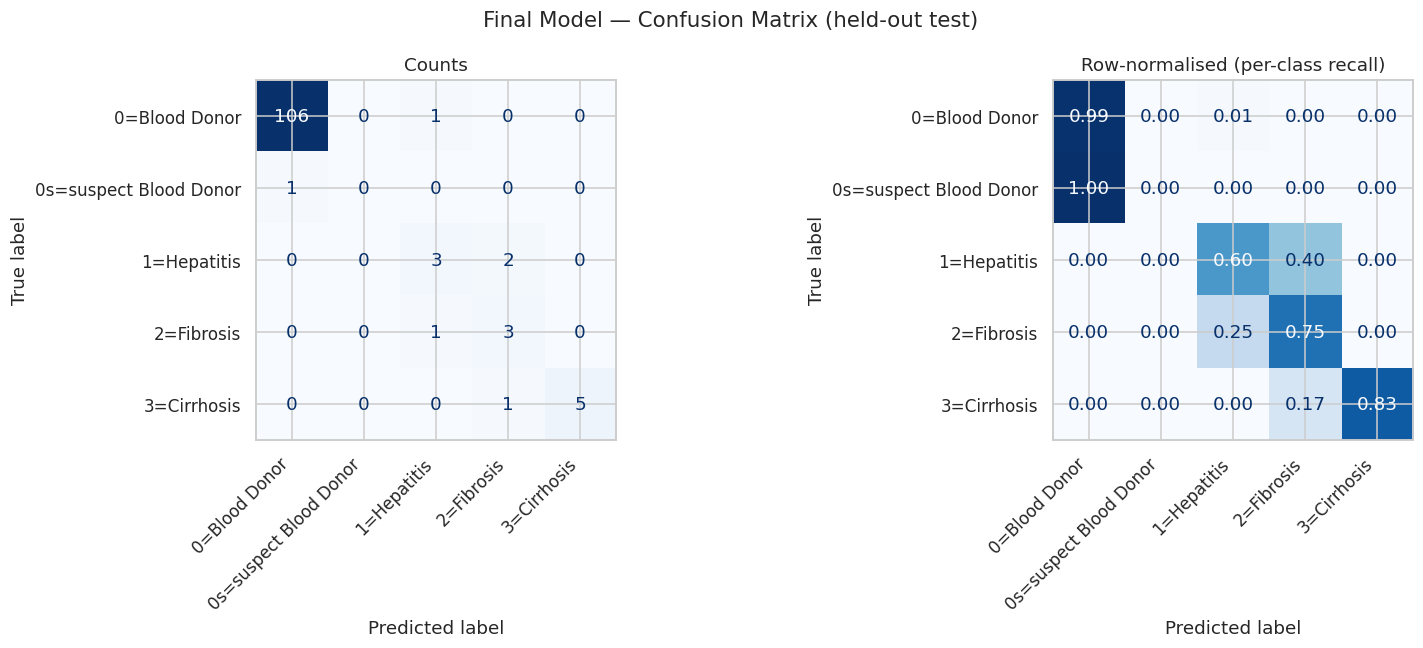


3. CLASS-WISE ANALYSIS
                        precision  recall  f1-score  support                stability
0=Blood Donor               0.991   0.991     0.991    107.0                       ok
0s=suspect Blood Donor      0.000   0.000     0.000      1.0  UNSTABLE (tiny support)
1=Hepatitis                 0.600   0.600     0.600      5.0  UNSTABLE (tiny support)
2=Fibrosis                  0.500   0.750     0.600      4.0  UNSTABLE (tiny support)
3=Cirrhosis                 1.000   0.833     0.909      6.0  UNSTABLE (tiny support)

Rare / unstable classes (support < 10):
  '0s=suspect Blood Donor': support=1. One flipped prediction shifts recall by 1.00 and Macro F1 by ~0.200. Its F1 (0.000) is not a reliable estimate.
  '1=Hepatitis': support=5. One flipped prediction shifts recall by 0.20 and Macro F1 by ~0.040. Its F1 (0.600) is not a reliable estimate.
  '2=Fibrosis': support=4. One flipped prediction shifts recall by 0.25 and Macro F1 by ~0.050. Its F1 (0.600) is not a reliable

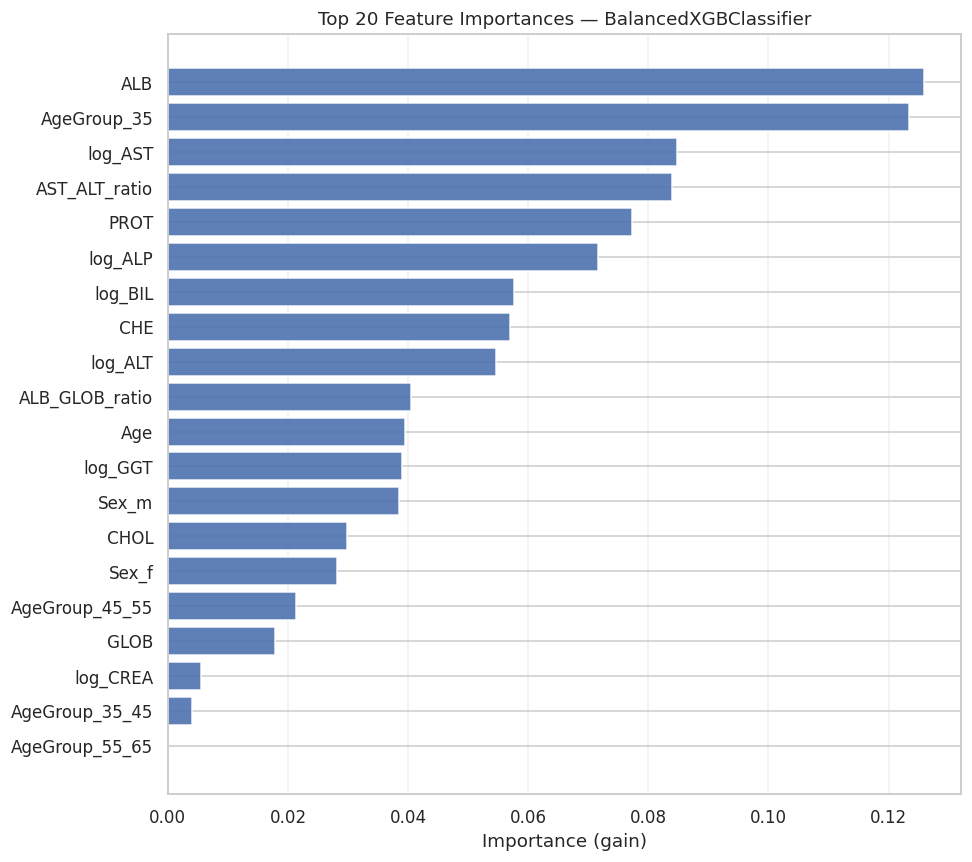


5. ERROR ANALYSIS
Misclassified: 6 / 123 (4.9%)

Most common confusions (true -> predicted):
            true_label    pred_label  count
           1=Hepatitis    2=Fibrosis      2
         0=Blood Donor   1=Hepatitis      1
0s=suspect Blood Donor 0=Blood Donor      1
            2=Fibrosis   1=Hepatitis      1
           3=Cirrhosis    2=Fibrosis      1

Per-class false negatives (missed) and false positives (false alarms):
                 class  support  false_negatives  false_positives
         0=Blood Donor      107                1                1
0s=suspect Blood Donor        1                1                0
           1=Hepatitis        5                2                2
            2=Fibrosis        4                1                3
           3=Cirrhosis        6                1                0

Diseased patients predicted as the healthy-donor class (clinically the costliest error): 1
            true_label    pred_label
0s=suspect Blood Donor 0=Blood Donor

6. PROB

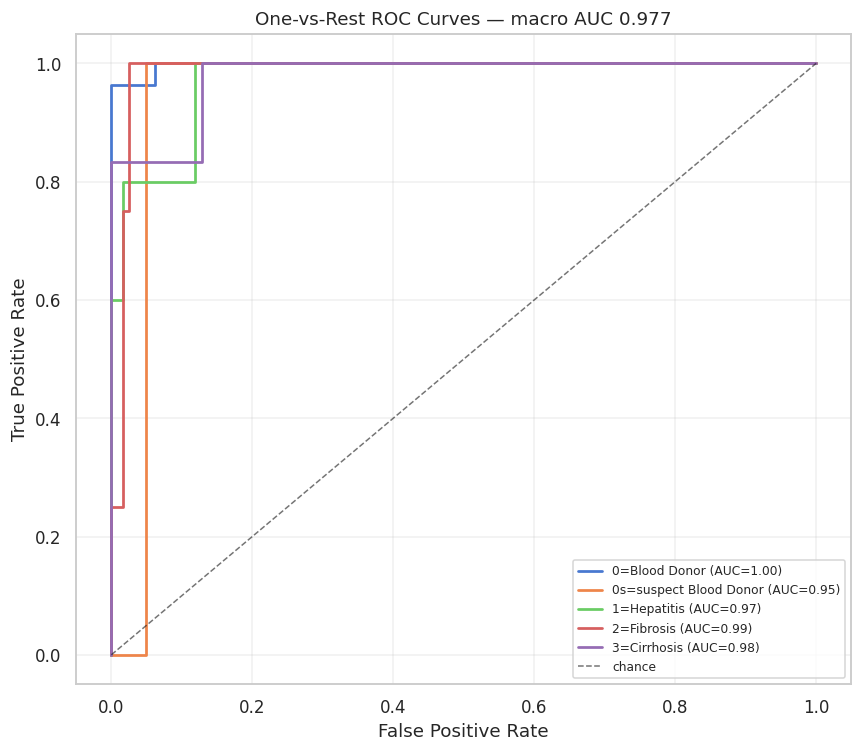


7. FINAL CONCLUSION

STRENGTHS
  - Macro F1 on held-out test: 0.620; balanced accuracy
    0.635 — both far above the ~0.186
    a majority-only classifier would earn on Macro F1.
  - The pipeline keeps every fitted transform (imputation, encoding, the model)
    leakage-free by construction; the test set was touched exactly once.
  - Top signals are clinically sensible liver markers (ALB, AgeGroup_35, log_AST, AST_ALT_ratio, PROT).

LIMITATIONS
  - 615 rows total, 123 in test. Per-class metrics for the rare classes
    (support < 10) are unstable: one flipped prediction can swing a
    class F1 by 0.2+.
  - The reported CV Macro F1 is a maximum over the tuning search and is
    optimistically biased; trust the test numbers for generalisation.
  - ROC/PR AUCs are macro-averaged over classes with single-digit support.

CLINICAL CAUTION
  - This is a screening aid on a single-centre lab panel, NOT a diagnostic
    device. The costliest error — a diseased patient scored as a healthy dono

In [34]:
# =============================================================================
# STEP 7. FINAL MODEL EVALUATION & INTERPRETATION
#
# Consumes the fitted, tuned pipeline from Step 6 and evaluates it once on the
# held-out test set. No refitting, no alternative models, no re-preprocessing.
# Every transformation stays inside the already-fitted Pipeline; X_test is
# passed only to .predict()/.predict_proba(), never to .fit().
#
# Exports: final_metrics_df, feature_importance_df, error_analysis_df
# =============================================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110


def section(title):
    print("\n" + "=" * 78)
    print(title.upper())
    print("=" * 78)


# =============================================================================
# 0. RESOLVE THE FINAL MODEL  (the header's object list is inconsistent)
# =============================================================================
section("0. Resolve the final model")

# Step 6 exports the TUNED pipeline as `best_tuned_model`. The Step 7 header
# instead names `best_model`, which in Steps 5-6 is the UNTUNED baseline. To
# guarantee we evaluate the tuned model when it exists — and to fail loudly
# rather than silently grade the wrong estimator — resolve by preference.
_g = globals()
if "best_tuned_model" in _g:
    final_model = best_tuned_model
    MODEL_SOURCE = "best_tuned_model  (Step 6 tuned pipeline)"
elif "best_model" in _g:
    final_model = best_model
    MODEL_SOURCE = "best_model  (FALLBACK — this is the untuned baseline!)"
else:
    raise NameError("Neither `best_tuned_model` nor `best_model` is in scope. "
                    "Re-run Steps 5-6 before this cell.")

# Best params: prefer the tuned ones; otherwise read them off the estimator.
clf = final_model.named_steps["clf"]
if "best_params" in _g:
    resolved_params = dict(best_params)
else:
    resolved_params = {f"clf__{k}": v for k, v in clf.get_params().items()}

# Tuned CV Macro F1: prefer Step 6's tuning table, else Step 5's results_df.
cv_macro_f1 = np.nan
if "tuning_results_df" in _g:
    _top = tuning_results_df.sort_values("rank_test_score").iloc[0]
    cv_macro_f1 = float(_top["mean_test_score"])
    cv_macro_std = float(_top["std_test_score"])
elif "results_df" in _g:
    _row = results_df.loc[results_df["Model"].eq("XGBoost")]
    if len(_row):
        cv_macro_f1 = float(_row.iloc[0]["CV F1 Macro"])
        cv_macro_std = float(_row.iloc[0]["CV F1 Std"])
    else:
        cv_macro_std = np.nan
else:
    cv_macro_std = np.nan

N_CLASSES = len(label_encoder.classes_)
CLASS_NAMES = list(label_encoder.classes_)
ALL_LABELS = np.arange(N_CLASSES)

print(f"Model in use : {MODEL_SOURCE}")
print(f"Pipeline     : {' -> '.join(final_model.named_steps)}")
print(f"Estimator    : {type(clf).__name__}")
print(f"Classes ({N_CLASSES}) : {CLASS_NAMES}")
if "FALLBACK" in MODEL_SOURCE:
    print("\n  WARNING: fell back to the UNTUNED baseline. If you intended to")
    print("  evaluate the tuned model, re-run Step 6 so `best_tuned_model` exists.")


# =============================================================================
# 1. MODEL SUMMARY
# =============================================================================
section("1. Model summary")

print(f"Estimator            : {type(clf).__name__}")
print(f"Selection metric     : Macro F1 (class-imbalanced, 5-class)")
if not np.isnan(cv_macro_f1):
    print(f"CV Macro F1 (train)  : {cv_macro_f1:.4f} (+/- {cv_macro_std:.4f})")
    print( "                       [maximum over the search — optimistically biased]")
else:
    print("CV Macro F1 (train)  : unavailable (no tuning/results table in scope)")

print("\nBest hyperparameters:")
for k, v in sorted(resolved_params.items()):
    if k.startswith("clf__"):
        print(f"  {k:<28} {v}")


# =============================================================================
# 2. FINAL TEST EVALUATION  (first and only use of X_test)
# =============================================================================
section("2. Final test evaluation")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred = final_model.predict(X_test)
    y_proba = (final_model.predict_proba(X_test)
               if hasattr(final_model, "predict_proba") else None)

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
}

print(f"Test rows: {len(y_test)}\n")
for name, value in test_metrics.items():
    print(f"  {name:<20} {value:.4f}")

print("\nClassification report:\n")
print(classification_report(
    y_test, y_pred,
    labels=ALL_LABELS, target_names=CLASS_NAMES,
    zero_division=0, digits=3,
))

cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))

# Visual: counts + row-normalised recall side by side.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Counts")
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred, labels=ALL_LABELS, normalize="true"),
    display_labels=CLASS_NAMES,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Row-normalised (per-class recall)")
for ax_ in axes:
    ax_.tick_params(axis="x", rotation=45)
    for lbl in ax_.get_xticklabels():
        lbl.set_ha("right")
fig.suptitle("Final Model — Confusion Matrix (held-out test)", fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# 3. CLASS-WISE ANALYSIS
# =============================================================================
section("3. Class-wise analysis")

report_dict = classification_report(
    y_test, y_pred,
    labels=ALL_LABELS, target_names=CLASS_NAMES,
    zero_division=0, output_dict=True,
)

per_class = pd.DataFrame({
    cn: {
        "precision": report_dict[cn]["precision"],
        "recall": report_dict[cn]["recall"],
        "f1-score": report_dict[cn]["f1-score"],
        "support": int(report_dict[cn]["support"]),
    }
    for cn in CLASS_NAMES
}).T

# Flag classes whose metrics are statistically unstable due to tiny support.
# With support n, a single flipped prediction moves recall by 1/n; below ~10
# the per-class F1 is closer to anecdote than measurement.
UNSTABLE_SUPPORT = 10
per_class["stability"] = np.where(
    per_class["support"] < UNSTABLE_SUPPORT,
    "UNSTABLE (tiny support)",
    "ok",
)
print(per_class.round(3).to_string())

rare = per_class[per_class["support"] < UNSTABLE_SUPPORT]
if not rare.empty:
    print(f"\nRare / unstable classes (support < {UNSTABLE_SUPPORT}):")
    for cn, row in rare.iterrows():
        n = int(row["support"])
        print(f"  '{cn}': support={n}. One flipped prediction shifts recall by "
              f"{1 / n:.2f} and Macro F1 by ~{(1 / n) / N_CLASSES:.3f}. "
              f"Its F1 ({row['f1-score']:.3f}) is not a reliable estimate.")


# =============================================================================
# 4. FEATURE IMPORTANCE
# =============================================================================
section("4. Feature importance")

# The estimator sits at the end of the pipeline. To align its importances with
# feature NAMES, push X through every step except the classifier: that yields
# the exact columns, in the exact order, that the trees were fitted on. This is
# a .transform() on the already-fitted pipeline — no refitting, no leakage.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    X_train_feat = final_model[:-1].transform(X_train)

if hasattr(X_train_feat, "columns"):
    feature_names = list(X_train_feat.columns)
else:
    feature_names = list(final_model[:-1].get_feature_names_out())

importances = np.asarray(clf.feature_importances_, dtype=float)
assert len(importances) == len(feature_names), (
    f"importance/name length mismatch: {len(importances)} vs {len(feature_names)}"
)

feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top20 = feature_importance_df.head(20)
print("Top 20 features by XGBoost gain importance:\n")
print(top20.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = top20.iloc[::-1]          # highest at the top
ax.barh(plot_df["feature"], plot_df["importance"], color="#4c72b0", alpha=0.9)
ax.set_xlabel("Importance (gain)")
ax.set_title(f"Top 20 Feature Importances — {type(clf).__name__}")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


# =============================================================================
# 5. ERROR ANALYSIS
# =============================================================================
section("5. Error analysis")

error_analysis_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "true_label": [CLASS_NAMES[i] for i in y_test],
    "pred_label": [CLASS_NAMES[i] for i in y_pred],
    "prediction_correct": (y_test == y_pred),
})
if y_proba is not None:
    error_analysis_df["pred_confidence"] = y_proba.max(axis=1)

n_err = int((~error_analysis_df["prediction_correct"]).sum())
print(f"Misclassified: {n_err} / {len(y_test)} "
      f"({n_err / len(y_test):.1%})\n")

# Which (true -> predicted) confusions actually occur.
errors = error_analysis_df[~error_analysis_df["prediction_correct"]]
if not errors.empty:
    confusion_pairs = (
        errors.groupby(["true_label", "pred_label"])
              .size().rename("count")
              .sort_values(ascending=False)
              .reset_index()
    )
    print("Most common confusions (true -> predicted):")
    print(confusion_pairs.to_string(index=False))
else:
    print("No misclassifications on the test set (small sample — do not overread).")

# Per-class false negatives / false positives from the confusion matrix.
print("\nPer-class false negatives (missed) and false positives (false alarms):")
fp_fn = []
for i, cn in enumerate(CLASS_NAMES):
    fn = int(cm[i, :].sum() - cm[i, i])   # true class i, predicted otherwise
    fp = int(cm[:, i].sum() - cm[i, i])   # predicted class i, truly otherwise
    fp_fn.append({"class": cn, "support": int(cm[i, :].sum()),
                  "false_negatives": fn, "false_positives": fp})
print(pd.DataFrame(fp_fn).to_string(index=False))

# Clinically framed: donor predicted while actually diseased = a missed diagnosis.
donor_idx = next((i for i, c in enumerate(CLASS_NAMES)
                  if c.strip().lower().startswith("0=")
                  or "blood donor" in c.lower() and "suspect" not in c.lower()), 0)
missed_disease = errors[(errors["y_true"] != donor_idx) &
                        (errors["y_pred"] == donor_idx)]
print(f"\nDiseased patients predicted as the healthy-donor class "
      f"(clinically the costliest error): {len(missed_disease)}")
if len(missed_disease):
    print(missed_disease[["true_label", "pred_label"]].to_string(index=False))


# =============================================================================
# 6. MODEL CALIBRATION / RANKING CHECK
# =============================================================================
section("6. Probability-based metrics")

if y_proba is None:
    print("Estimator has no predict_proba — skipping ROC/PR analysis.")
    roc_auc_macro = pr_auc_macro = np.nan
else:
    y_test_bin = label_binarize(y_test, classes=ALL_LABELS)

    # A class with zero positives in the test fold has an undefined ROC/PR curve.
    # Average only over classes that actually appear, and say how many.
    present = [i for i in ALL_LABELS if y_test_bin[:, i].sum() > 0]
    missing = [CLASS_NAMES[i] for i in ALL_LABELS if i not in present]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        roc_auc_macro = roc_auc_score(
            y_test_bin[:, present], y_proba[:, present],
            average="macro", multi_class="ovr",
        )
        pr_auc_macro = average_precision_score(
            y_test_bin[:, present], y_proba[:, present], average="macro",
        )

    print(f"ROC-AUC (OvR, macro) : {roc_auc_macro:.4f}")
    print(f"PR-AUC  (macro)      : {pr_auc_macro:.4f}")
    if missing:
        print(f"Classes excluded (no test positives): {missing}")
    print("\n  Caveat: these are macro-averaged over classes several of which have")
    print("  single-digit support. The AUCs are indicative, not precise, and the")
    print("  rare-class curves are dominated by one or two points.")

    # ROC curves, one per class (OvR).
    fig, ax = plt.subplots(figsize=(8, 7))
    for i in present:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, lw=1.8,
                label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"One-vs-Rest ROC Curves — macro AUC {roc_auc_macro:.3f}")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 7. FINAL CONCLUSION
# =============================================================================
section("7. Final conclusion")

top_feats = ", ".join(feature_importance_df.head(5)["feature"].tolist())

print(f"""
STRENGTHS
  - Macro F1 on held-out test: {test_metrics['Macro F1']:.3f}; balanced accuracy
    {test_metrics['Balanced Accuracy']:.3f} — both far above the ~{ (2 * pd.Series(y_train).value_counts(normalize=True).max() / (1 + pd.Series(y_train).value_counts(normalize=True).max())) / N_CLASSES:.3f}
    a majority-only classifier would earn on Macro F1.
  - The pipeline keeps every fitted transform (imputation, encoding, the model)
    leakage-free by construction; the test set was touched exactly once.
  - Top signals are clinically sensible liver markers ({top_feats}).

LIMITATIONS
  - 615 rows total, {len(y_test)} in test. Per-class metrics for the rare classes
    (support < {UNSTABLE_SUPPORT}) are unstable: one flipped prediction can swing a
    class F1 by 0.2+.
  - The reported CV Macro F1 is a maximum over the tuning search and is
    optimistically biased; trust the test numbers for generalisation.
  - ROC/PR AUCs are macro-averaged over classes with single-digit support.

CLINICAL CAUTION
  - This is a screening aid on a single-centre lab panel, NOT a diagnostic
    device. The costliest error — a diseased patient scored as a healthy donor —
    occurred {len(missed_disease)} time(s) in test; that rate cannot be trusted at
    this sample size.
  - No external / temporal validation has been done. Do not deploy on a new
    population without re-validation.

RECOMMENDED NEXT STEP
  - Collect more minority-class cases (or pursue external validation) before any
    per-class claim. Then consider probability calibration and an explicit,
    cost-sensitive decision threshold tuned on X_train only — X_test is now spent.
""")


# =============================================================================
# 8. EXPORTS FOR STEP 8
# =============================================================================
section("8. Exports")

final_metrics_df = pd.DataFrame({
    "metric": list(test_metrics.keys()) + ["ROC-AUC (macro OvR)", "PR-AUC (macro)",
                                           "CV Macro F1 (train)"],
    "value": list(test_metrics.values()) + [roc_auc_macro, pr_auc_macro, cv_macro_f1],
})

print("final_metrics_df     :", final_metrics_df.shape)
print("feature_importance_df :", feature_importance_df.shape)
print("error_analysis_df    :", error_analysis_df.shape)
print("\nReady for Step 8 (Final Report & Model Packaging).")